In [1]:
import os

import tifffile
import numpy as np
import cv2
%matplotlib inline
from matplotlib import pyplot as plt
from math import sqrt, ceil, hypot, degrees, atan

from scipy.ndimage.morphology import binary_fill_holes
from scipy import interpolate
from skimage import feature
from skimage.filters import threshold_otsu, gaussian
from skimage.transform import rotate, SimilarityTransform
from skimage.morphology import disk, erosion, remove_small_holes, binary_opening, remove_small_objects

from skimage.io import imsave
from readlif.reader import LifFile

In [2]:
src_filepath = '/Users/christina.bukas/Documents/AI_projects/datasets/220902_No_contraction_curare'
dst_filepath = '/Users/christina.bukas/Documents/AI_projects/datasets/dev_220902_No_contraction_curare'
files = [file for file in os.listdir(src_filepath) if file.endswith('.lif')]
print('Dataset includes ', len(files), ' videos')

Dataset includes  12  videos


In [3]:
for file in files:
    img = LifFile(os.path.join(src_filepath, file))
    img_0 = img.get_image(0)
    img_list   = [i for i in img_0.get_iter_t(c=0, z=0)]
    img_array = np.stack(img_list)
    tif_name = file.split('.')[0]+'.tif'
    imsave(os.path.join(dst_filepath, tif_name), img_array)

### All videos have the same size in pixels but varying lengths

In [4]:
files = [file for file in os.listdir(dst_filepath) if file.endswith('.tif')]
for file in files:
    img=tifffile.imread(os.path.join(dst_filepath, file))
    print('File: ', file, 'Shape: ', img.shape)

File:  O1409_1b.tif Shape:  (1813, 256, 256)
File:  O2652_2b_curare.tif Shape:  (3147, 256, 256)
File:  O2542_1c_curare.tif Shape:  (3147, 256, 256)
File:  O2573_1b_curare.tif Shape:  (3147, 256, 256)
File:  O2652_1b_curare.tif Shape:  (3147, 256, 256)
File:  O2542_2b_curare.tif Shape:  (3147, 256, 256)
File:  O2652_1a_curare.tif Shape:  (3147, 256, 256)
File:  O1498_1a_curare.tif Shape:  (1208, 256, 256)
File:  O1450_1b_curare.tif Shape:  (1208, 256, 256)
File:  O3199_1_curare.tif Shape:  (3015, 256, 256)
File:  P766_1b.tif Shape:  (3147, 256, 256)
File:  P918_1b_recovery_curare.tif Shape:  (3114, 256, 256)


# Useful functions for border extraction

In [5]:
def remove_border_points(border_points):
    '''Remove the white pixels on border of image'''
    border_x = list(border_points[0])
    border_y = list(border_points[1])
    i = 0
    remove_ids = []
    for x, y in zip(border_x, border_y):
        if x<2 or x>252 or y<5 or y>252: remove_ids.append(i)
        i+=1
    for i in reversed(remove_ids):
        border_x.pop(i)
        border_y.pop(i)
    return (np.array(border_x), np.array(border_y))

def extract_border(img_slice, sigma_smooth=2, sigma_edge=3):
    '''
    Extract the border from a single frame, by following:
    1. Threshold image using Otsu thresholding
    2. Apply morphological opening and fill any holes in the binary image
    3. Compute edges using the Canny edge Detection algorithm
    4. Remove white pixels from border of image
    6. Return border coordinates and binary image
    '''
    img_smooth = gaussian(img_slice, sigma_smooth)
    thresh = threshold_otsu(img_smooth)
    image_thresh = img_smooth > thresh
    image_thresh = binary_opening(image_thresh, disk(4))
    image_thresh = remove_small_objects(image_thresh, min_size=400)
    
    edges = feature.canny(image_thresh, sigma_edge)
    x,y = remove_border_points((np.where(edges)))

    return (x,y), image_thresh 

def sort_border(x,y):
    ''' Sort border pixels such that the signal coordinates are continuous'''
    sorted_x = x[np.argsort(x)]
    sorted_y = y[np.argsort(y)]
    max_dist_x = sorted_x[-1] - sorted_x[0]
    max_dist_y = sorted_y[-1] - sorted_y[0]
    if max_dist_x > max_dist_y: point0 = np.where(x==sorted_x[0])[0][0]
    else: point0 = np.where(y==sorted_y[0])[0][0]
    sorted_ids = np.argsort((x-x[point0])**2+(y-y[point0])**2) # x+y
    x = x[sorted_ids]
    y = y[sorted_ids]
    return (x,y)

def get_normals(border_points, track_points, length, img_size):
    ''' Get the normals of the points we wish to track on border'''
    border_points = np.asarray(border_points).T
    track_points = np.asarray(track_points).T
    static_points_x = []
    static_points_y = []
    for point in track_points: 
        idx=np.where(np.all(point==border_points, axis=1))[0][0]
        if idx==border_points.shape[0]-1:
            x0, y0, xa, ya = point[0], point[1], border_points[idx-1, 0], border_points[idx-1, 1] 
            dx, dy = x0-xa, y0-ya
        else:
            x0, y0, xa, ya = point[0], point[1], border_points[idx+1, 0], border_points[idx+1, 1]
            dx, dy = xa-x0, ya-y0
        norm = hypot(dx, dy) * 1/length
        dx /= norm
        dy /= norm
        dx0 = max(0, min(x0-dy, img_size))
        dy0 = max(0, min(y0+dx, img_size))
        #plt.plot((x0, dx0), (y0, dy0))    # plot the normals
        static_points_x.append(dx0)
        static_points_y.append(dy0)
    return (static_points_x, static_points_y)   

def compute_static_on_img_border(image_bin):
    ''' Get a point on the border of the image which is mostly organoid'''
    # get row or col on border of image
    image_top = 1 - image_bin[0,:]
    image_bottom = 1 - image_bin[-1,:]
    image_left = 1 - image_bin[:,0]
    image_right = 1 - image_bin[:,-1]
    
    # find num of pixels on these rows, columns
    image_top_sum = np.sum(image_top)
    image_bottom_sum = np.sum(image_bottom)
    image_left_sum = np.sum(image_left)
    image_right_sum = np.sum(image_right)
    images_border_sums = [image_top_sum, image_bottom_sum, image_left_sum, image_right_sum]
    larger_border_id = images_border_sums.index(max(images_border_sums))
    
    # and define static point in middle of border row or col with most black(i.e. organoid) pixels
    if larger_border_id==0:
        static_point = (0,128)
    elif larger_border_id==1:
        static_point = (256,128)
    elif larger_border_id==2:
        static_point = (128,0)
    else:
        static_point = (128,256)
    return np.array(static_point)

def line_function(x, ys, ye, xs, xe):
    ''' Find y for a given x when we know start and end point of line '''
    return round(x*(ys-ye)/(xs-xe)+(ye*xs-xe*ys)/(xs-xe))

def line_approx(img, min_point, max_point, length=30):
    '''NEED TO CONFIRM THIS WORKS CORRECTLY!!!'''
    x1,y1 = min_point
    x2,y2 = max_point 
    xs = min(x1,x2)
    xe = max(x1,x2)
    ys = min(y1,y2)
    ye = max(y1,y2)
    
    xm = max((x2-x1)//2, (x1-x2)//2)
    ym = max((y2-y1)//2, (y1-y2)//2)
    img_l = img[:xm,:ym]
    img_r = img[xm:,ym:]
    if np.mean(img_l)> np.mean(img_r):
        # the organoid is on the left of the border
        sign = -1
    else: sign = 1
    length = sign*length
    for x in range(xm-10,xm+10):
        x0, y0, xa, ya = xm, ym, xm+1,line_function(xm+1, ys, ye, xs, xe)
        dx, dy = x0-xa, y0-ya
        norm = hypot(dx, dy) * 1/length
        dx /= norm
        dy /= norm
        dx0 = max(0, min(x0-dy, 255))
        dy0 = max(0, min(y0+dx, 255))
        return (dx0,dy0)
    
def get_tracking_points(frame0, num_track_points=10, num_static_points=1, method='img-border', static_distance=-30):
    '''Given a frame return the points on norder to be tracked along with statis point(s) from which the distance need be computed'''
    
    #get the organoid border and remove image border pixels
    (x,y), image_bin = extract_border(frame0)    
    # sort the signal so that array of coordinates is continuous
    border_points = sort_border(x, y)
    
    # get points on border of organoid to track
    num_border_points = border_points[0].shape[0]
    idx = np.round(np.linspace(0, num_border_points - 1, num_track_points)).astype(int)
    track_points = (border_points[0][idx], border_points[1][idx])
    
    # get one or multiple static points depending on num_static_points var.
    if num_static_points==1 and method=='line-approx':
        static_points = line_approx(frame0, (x[-1],y[-1]), (x[0], y[0]))
    elif num_static_points==1 and method=='img-border':
        static_points = compute_static_on_img_border(image_bin)
    else:
        static_points = get_normals(border_points, track_points, length=static_distance, img_size=frame0.shape[1])
    
    return border_points, track_points, static_points

def get_border_angle(x , y):
    ''' Compute the angle of the border considering it as a line from first to last point'''
    xl = x[-1] - x[0]
    yl = y[-1] - y[0]
    theta = degrees(atan(xl/yl))
    return theta


# Useful functions for tracking points in video

In [6]:
def convert_vid2rgb(vid):
    '''Convert grayscale video to RGB'''
    vid_color = np.zeros((vid.shape[0], vid.shape[1], vid.shape[2], 3))
    for i in range(vid.shape[0]):
        frame = vid[i,:,:]
        vid_color[i] = cv2.cvtColor(frame, cv2.COLOR_GRAY2RGB)
    return vid_color.astype(np.uint8)

# https://www.geeksforgeeks.org/python-opencv-optical-flow-with-lucas-kanade-method/
def track_points_in_vid(filename, vid, track_points, static_points, lose_points= True, view=False, wait=100, subsample=1, out=None):
        
    if view: 
        vid_color = convert_vid2rgb(vid) # convert video to rgb format
        cv2.destroyAllWindows()

    # Parameters for lucas kanade optical flow
    lk_params = dict( winSize = (35, 35), #(15, 15) (35, 35)
                      maxLevel = 2, #2,
                      criteria = (cv2.TERM_CRITERIA_EPS | cv2.TERM_CRITERIA_COUNT, 10, 0.03))

    # Take first frame and convert points from tuples to arrays
    old_gray = vid[0].copy() 

    # if a single static point
    #if len(static_points.shape)==1: static_points = static_points[:, np.newaxis]
        
    track_points = np.asarray(track_points).T
    track_points = track_points[:, np.newaxis, :].astype(np.float32) # shape is (10,1,2) for 10 points to track
    tracked_points_vid = np.zeros((track_points.shape[0], vid.shape[0])) # shape is e.g. [10, 1, 2, 1000]
    if len(static_points.shape)==1:
        tracked_points_vid[:, 0] = np.sqrt((track_points[:, 0, 0] - static_points[0])**2 + (track_points[:, 0, 1] - static_points[1])**2)
    else:
        static_points = np.asarray(static_points).T
        static_points = static_points[:, np.newaxis, :].astype(np.float32)
        tracked_points_vid[:, 0] = np.sqrt((track_points[:, 0, 0] - static_points[:, 0, 0])**2 + (track_points[:, 0, 1] - static_points[:, 0, 1])**2)

    final_tracked_points_vid = tracked_points_vid.copy()
    original_ids = np.arange(10)
    points_lost = 0
    frame0 = vid_color[0]
    for pid in range(track_points.shape[0]):
        frame0 = cv2.circle(frame0, (track_points[pid,0,1], track_points[pid,0,0]), 5, (0, 255, 0), -1) # add tracked point
    frames = [frame0]

    for frame_id in range(1, vid.shape[0]//subsample):   
        
        if view: frame = vid_color[frame_id] 
        frame_gray = vid[frame_id] 

        if lose_points:
            # calculate optical flow
            tracked_points, st, err = cv2.calcOpticalFlowPyrLK(old_gray, frame_gray, track_points, None, **lk_params) #, flags = cv2.OPTFLOW_USE_INITIAL_FLOW)
            if tracked_points is not None:
                # Select good points
                good_ids, _ = np.where(st==1)
                bad_ids, _ = np.where(st==0)
                if len(bad_ids)!=0:
                    original_ids_final = original_ids[bad_ids]                
                    final_tracked_points_vid[original_ids_final, :] = tracked_points_vid[original_ids_final, :]
                    original_ids = np.delete(original_ids, bad_ids, 0)
                good_new_points = tracked_points[st == 1]
                if len(static_points.shape)==1:
                    tracked_points_vid[original_ids, frame_id] = np.sqrt((good_new_points[:,0] - static_points[0])**2 + (good_new_points[:,1] - static_points[1])**2)
                else: 
                    static_points = static_points[st==1]
                    static_points = static_points[:, np.newaxis, :]
                    #tracked_points_vid[original_ids, frame_id, :] = good_new_points
                    tracked_points_vid[original_ids, frame_id] = np.sqrt((good_new_points[:,0] - static_points[:,0])**2 + (good_new_points[:,1] - static_points[:,1])**2)
                track_points = good_new_points.reshape(-1, 1, 2)
                
        else:
            tracked_points1, _, _ = cv2.calcOpticalFlowPyrLK(old_gray, frame_gray, track_points, None, **lk_params) 
            tracked_points0, _, _ = cv2.calcOpticalFlowPyrLK(frame_gray, old_gray, tracked_points1, None, **lk_params)
            d = abs(track_points-tracked_points0).reshape(-1, 2).max(-1)
            good = d < 1 
            new_tracks = []

            for i, (tr, (x, y), good_flag) in enumerate(zip(track_points, tracked_points1.reshape(-1, 2), good)):
                if not good_flag: tr = (tr[0,0], tr[0,1])
                else: tr = (x, y)
                new_tracks.append(tr)
                if len(static_points.shape)==1:
                    final_tracked_points_vid[i, frame_id] = sqrt((tr[0] - static_points[0])**2 + (tr[1] - static_points[1])**2)
                else: 
                    final_tracked_points_vid[i, frame_id] = sqrt((tr[0] - static_points[i,0])**2 + (tr[1] - static_points[i, 1])**2)
            track_points = np.array(new_tracks)
            track_points = track_points[:, np.newaxis, :]
                
        # draw the tracks
        for i, new_point in enumerate(track_points):
            if len(static_points.shape)==1: static_x, static_y = static_points.ravel()
            else: static_x, static_y = static_points[i].ravel()
            new_x, new_y = new_point.ravel()
            if view:
                frame = cv2.circle(frame, (new_y, new_x), 5, (0, 255, 0), -1) # add tracked point
                frame = cv2.circle(frame, (static_y, static_x), radius=5, color=(0, 255, 0), thickness=-1)
                frame = cv2.line(frame, (static_y, static_x), (new_y, new_x), (0, 0, 255), thickness=2)            

        # Updating previous frame and points 
        old_gray = frame_gray.copy()

        if out: out.write(frame)
        frames.append(frame)
        
        if view:
            cv2.namedWindow(filename) 
            cv2.moveWindow(filename, 200,200) 
            cv2.imshow(filename, frame)
            k = cv2.waitKey(wait)
            if k == 27:
                break
    
    if lose_points:   
        final_tracked_points_vid[original_ids, :] = tracked_points_vid[original_ids, :]
        points_lost = final_tracked_points_vid.shape[0] - original_ids.shape[0]
        
    return final_tracked_points_vid, points_lost, out, frames


## Extract the organoid border from the first frame of all videos and visualize results

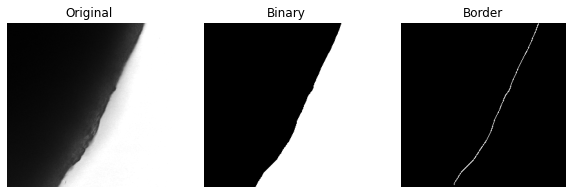

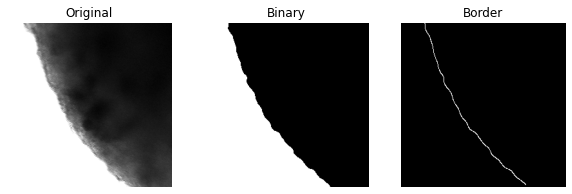

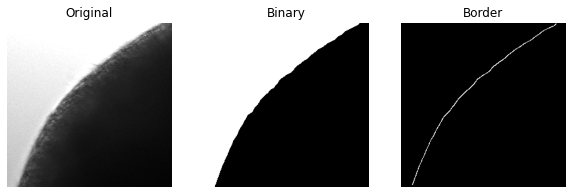

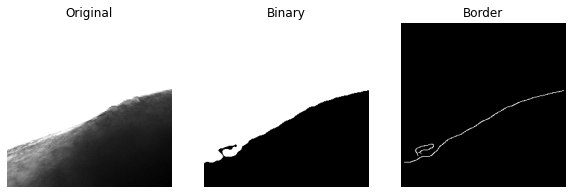

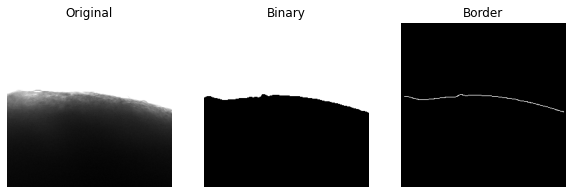

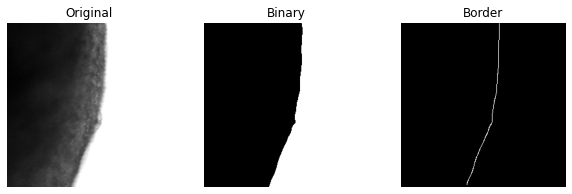

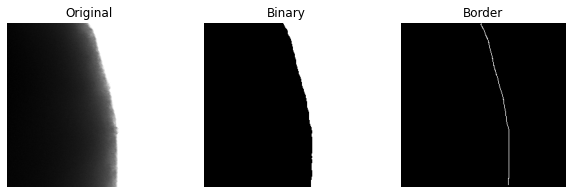

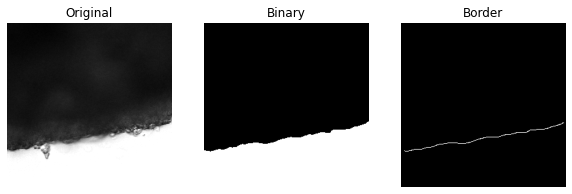

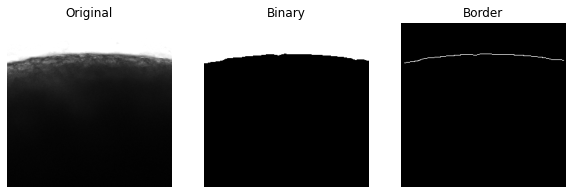

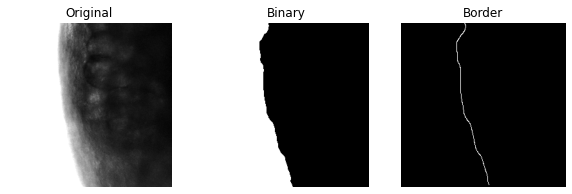

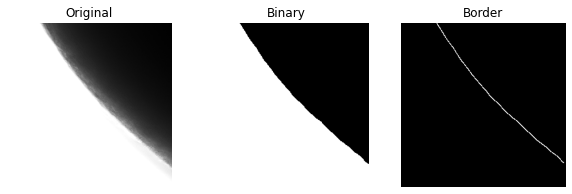

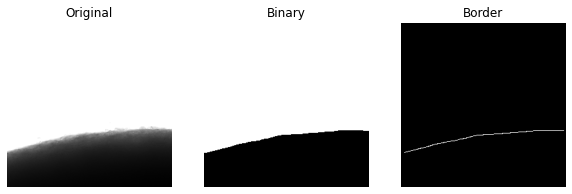

In [7]:
filepath = dst_filepath

for file in files:
    slice_id = 0
    img = tifffile.imread(os.path.join(filepath, file))
    img_slice = img[slice_id,:,:]
    (x,y), image_thresh = extract_border(img_slice, sigma_smooth=2, sigma_edge=3)
    edges = np.zeros(img_slice.shape)
    edges[x,y] = 1
    
    fig, ax = plt.subplots(1,3, figsize=(10,100))
    #fig.suptitle(file)
    ax[0].imshow(img_slice, cmap='gray')
    ax[0].title.set_text('Original')
    ax[0].axis('off')
    ax[1].imshow(image_thresh, cmap='gray')
    ax[1].title.set_text('Binary')
    ax[1].axis('off')
    ax[2].imshow(edges, cmap='gray')
    ax[2].title.set_text('Border')
    ax[2].axis('off')

## Display videos of border extraction at every frame

Uncomment end if you want to find out how many points are on border

In [8]:
# uncomment if you would reather save a video with output rather than visualise live
# out = cv2.VideoWriter('output.mp4',cv2.VideoWriter_fourcc('m', 'p', '4', 'v'), 100, (512,200))

# uncomment to find number of points on border
num_pixel_edges = []

subsample=20

for i in range(len(files)):
    print(files[i])
    cv2.destroyAllWindows()
    example_file = files[i]
    vid = tifffile.imread(os.path.join(filepath, example_file))
    frames=[]

    for frame_id in range(vid.shape[0]//subsample):   
        (x,y), _ = extract_border(vid[frame_id], sigma_smooth=2, sigma_edge=3)
        x, y = sort_border(x, y)
        #num_pixel_edges.append(x.shape[0]) # uncomment to find number of points on border
        
        # Rotate border so that is always parallel to x-axis
        theta = get_border_angle(x , y)
        mask = np.zeros(vid[frame_id].shape, dtype=bool)
        mask[(x,y)] = True #size 256, 256
        mask_r = rotate(mask, theta, resize=True) # shape usually 305,305
        
        # Pad so we alwyas have a fixed size image
        resize_size = (512 - mask_r.shape[0], 512 - mask_r.shape[1])
        mask_r = np.pad(mask_r, ((resize_size[0]//2+mask_r.shape[0]%2, resize_size[0]//2), (resize_size[1]//2+mask_r.shape[1]%2, resize_size[1]//2)))
    
        # Translate always relative to middle of image 
        if frame_id==0: mean_x = int(np.mean(np.where(mask_r)[0]))
        mask_r = mask_r[mean_x-100:mean_x+100,:]
        
        # Display
        frame = cv2.cvtColor((mask_r*255).astype(np.uint8),cv2.COLOR_GRAY2RGB)
        #out.write(frame) # uncomment for video saving
        cv2.namedWindow(files[i]) 
        cv2.moveWindow(files[i], 200,200) 
        cv2.imshow(files[i], (mask_r*255).astype(np.uint8))
        k = cv2.waitKey(1)
        if k == 27: break
            
# out.release() # uncomment for video saving

# uncomment to find number of points on border
# num_pixel_edges = np.array(num_pixel_edges)
# print('Average number of pixels on border: ', np.mean(num_pixel_edges))
# print('Std of border pixels: ', np.std(num_pixel_edges))


O1409_1b.tif
O2652_2b_curare.tif
O2542_1c_curare.tif
O2573_1b_curare.tif
O2652_1b_curare.tif
O2542_2b_curare.tif
O2652_1a_curare.tif
O1498_1a_curare.tif
O1450_1b_curare.tif
O3199_1_curare.tif
P766_1b.tif
P918_1b_recovery_curare.tif


## Lets try with tracking ten points along the border and extracting signal from these
### Approach 1: Compute the normals of the points to define static points perpendicular to border

The points we are tracking should always have the same physical distance between points on border

Opening file: Weak contraction.lif - O1318_3a.tif
Number of frames in video:  796
Opening file: 220516_No contraction videos.lif - O1450_2 curare II.tif
Number of frames in video:  1208


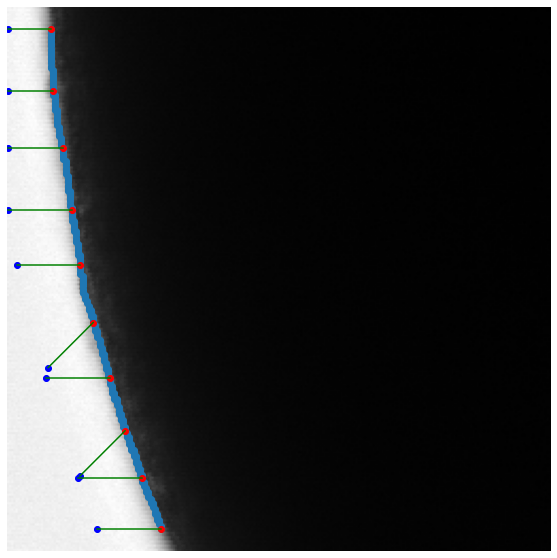

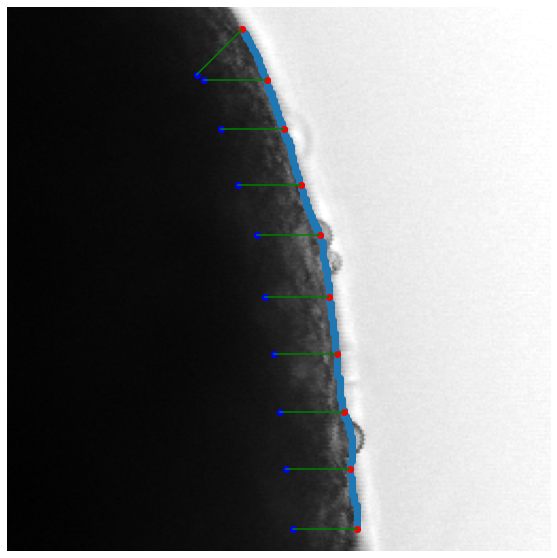

In [7]:
for i in range(1,3): #len(files)):
    example_file = files[i]

    print('Opening file:' , example_file)
    vid = tifffile.imread(os.path.join(filepath, example_file))
    print('Number of frames in video: ', vid.shape[0])
    border_points, track_points, static_points = get_tracking_points(vid[0])
    
    plt.figure(figsize=(10,10))
    plt.imshow(vid[0], cmap='gray')
    plt.axis('off')
    plt.scatter(border_points[1],border_points[0])
    plt.scatter(track_points[1], track_points[0], c='r')
    plt.scatter(static_points[1], static_points[0], c='b')
    for i in range(len(static_points[0])): 
        plt.plot((track_points[1][i], static_points[1][i]), (track_points[0][i], static_points[0][i]), c='g')


### Approach 2: Compute distance from one static point inside organoid

Opening file: 220516_No contraction videos.lif - O1445_2a.tif
Number of frames in video:  1208
Opening file: Weak contraction.lif - O1318_3a.tif
Number of frames in video:  796
Opening file: 220516_No contraction videos.lif - O1450_2 curare II.tif
Number of frames in video:  1208
Opening file: Strong contraction.lif - O1319_1a.tif
Number of frames in video:  1813
Opening file: Weak contraction.lif - O1318_2a.tif
Number of frames in video:  1813
Opening file: Strong contraction.lif - O1464_1a.tif
Number of frames in video:  1208
Opening file: Strong contraction.lif - O1468_1b.tif
Number of frames in video:  1208
Opening file: Strong contraction.lif - O1466_2a.tif
Number of frames in video:  1208
Opening file: Weak contraction.lif - O1443_1b.tif
Number of frames in video:  1509
Opening file: 220516_No contraction videos.lif - O1319_3a.tif
Number of frames in video:  1813
Opening file: Strong contraction.lif - O1464_2a.tif
Number of frames in video:  1208
Opening file: Weak contraction.li

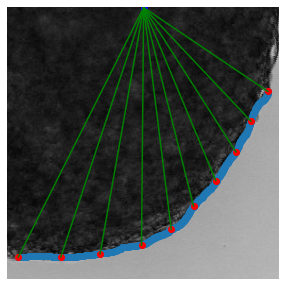

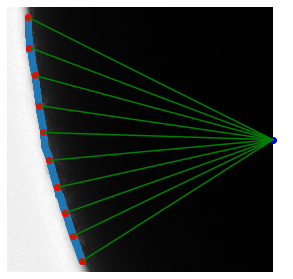

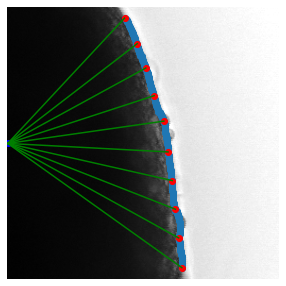

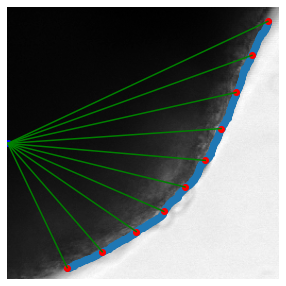

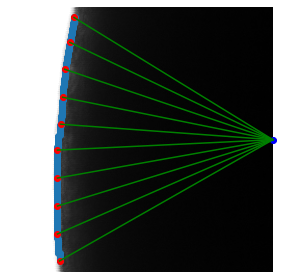

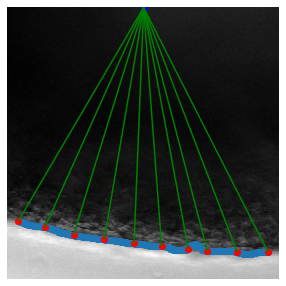

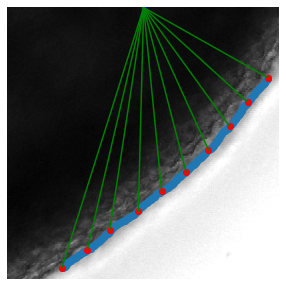

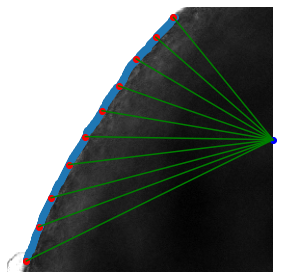

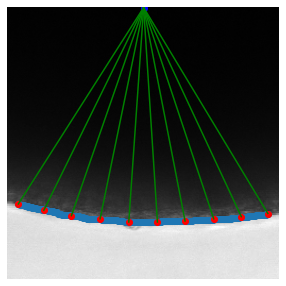

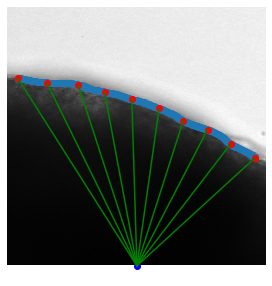

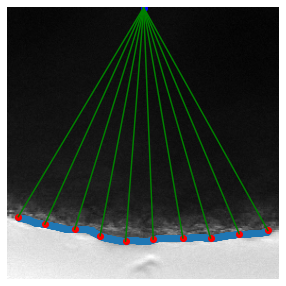

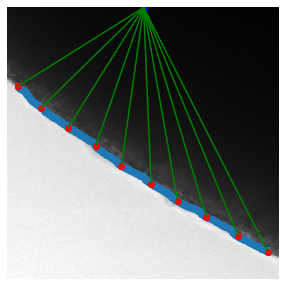

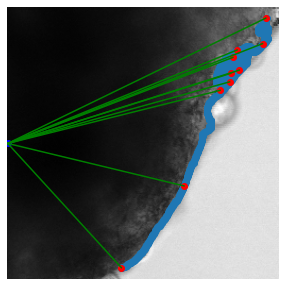

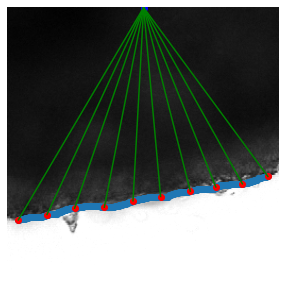

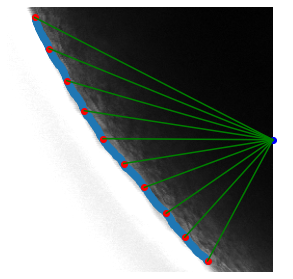

In [10]:
for i in range(len(files)):
    example_file = files[i]

    print('Opening file:' , example_file)
    vid = tifffile.imread(os.path.join(filepath, example_file))
    print('Number of frames in video: ', vid.shape[0])
    border_points, track_points, static_point = get_tracking_points(vid[0])

    plt.figure(figsize=(5,5))
    plt.imshow(vid[0], cmap='gray')
    plt.axis('off')
    plt.scatter(border_points[1],border_points[0])
    plt.scatter(track_points[1], track_points[0], c='r')
    plt.scatter(static_point[1], static_point[0], c='b')
    for i in range(len(static_points[0])): 
        plt.plot((track_points[1][i], static_point[1]), (track_points[0][i], static_point[0]), c='g')
    


### Step 2: Track points and compute distance from static points

In [48]:
# uncomment to save output video with result
#out = cv2.VideoWriter('output.mp4',cv2.VideoWriter_fourcc('m', 'p', '4', 'v'), 35, (256,256))
out = None
subsample=10 # change to 1 to view entire video not a subsample of it

for i in range(len(files)): # add here to repeat for all videos
    filename = files[i]
    cv2.destroyAllWindows()
    print('Opening file:' , filename)
    vid = tifffile.imread(os.path.join(filepath, filename))
    _, track_points, static_points = get_tracking_points(vid[0])
    # add out as parameter if you wish to save video
    distances, points_lost, out = track_points_in_vid(filename, vid, track_points, static_points, lose_points=False, view=True, wait=1, subsample=subsample, out=out) # view video and set frame rate
    #print('Done! Points lost during tracking: ', points_lost)
    
#out.release()

Opening file: 220516_No contraction videos.lif - O1445_2a.tif
Opening file: Weak contraction.lif - O1318_3a.tif
Opening file: 220516_No contraction videos.lif - O1450_2 curare II.tif
Opening file: Strong contraction.lif - O1319_1a.tif
Opening file: Weak contraction.lif - O1318_2a.tif
Opening file: Strong contraction.lif - O1464_1a.tif
Opening file: Strong contraction.lif - O1468_1b.tif
Opening file: Strong contraction.lif - O1466_2a.tif
Opening file: Weak contraction.lif - O1443_1b.tif
Opening file: 220516_No contraction videos.lif - O1319_3a.tif
Opening file: Strong contraction.lif - O1464_2a.tif
Opening file: Weak contraction.lif - O1318_1b.tif
Opening file: Weak contraction.lif - O1301_3a.tif
Opening file: 220516_No contraction videos.lif - O1498_1a curare.tif
Opening file: 220516_No contraction videos.lif - O1463_1b.tif


### Step 3: Extract signals - do for last video

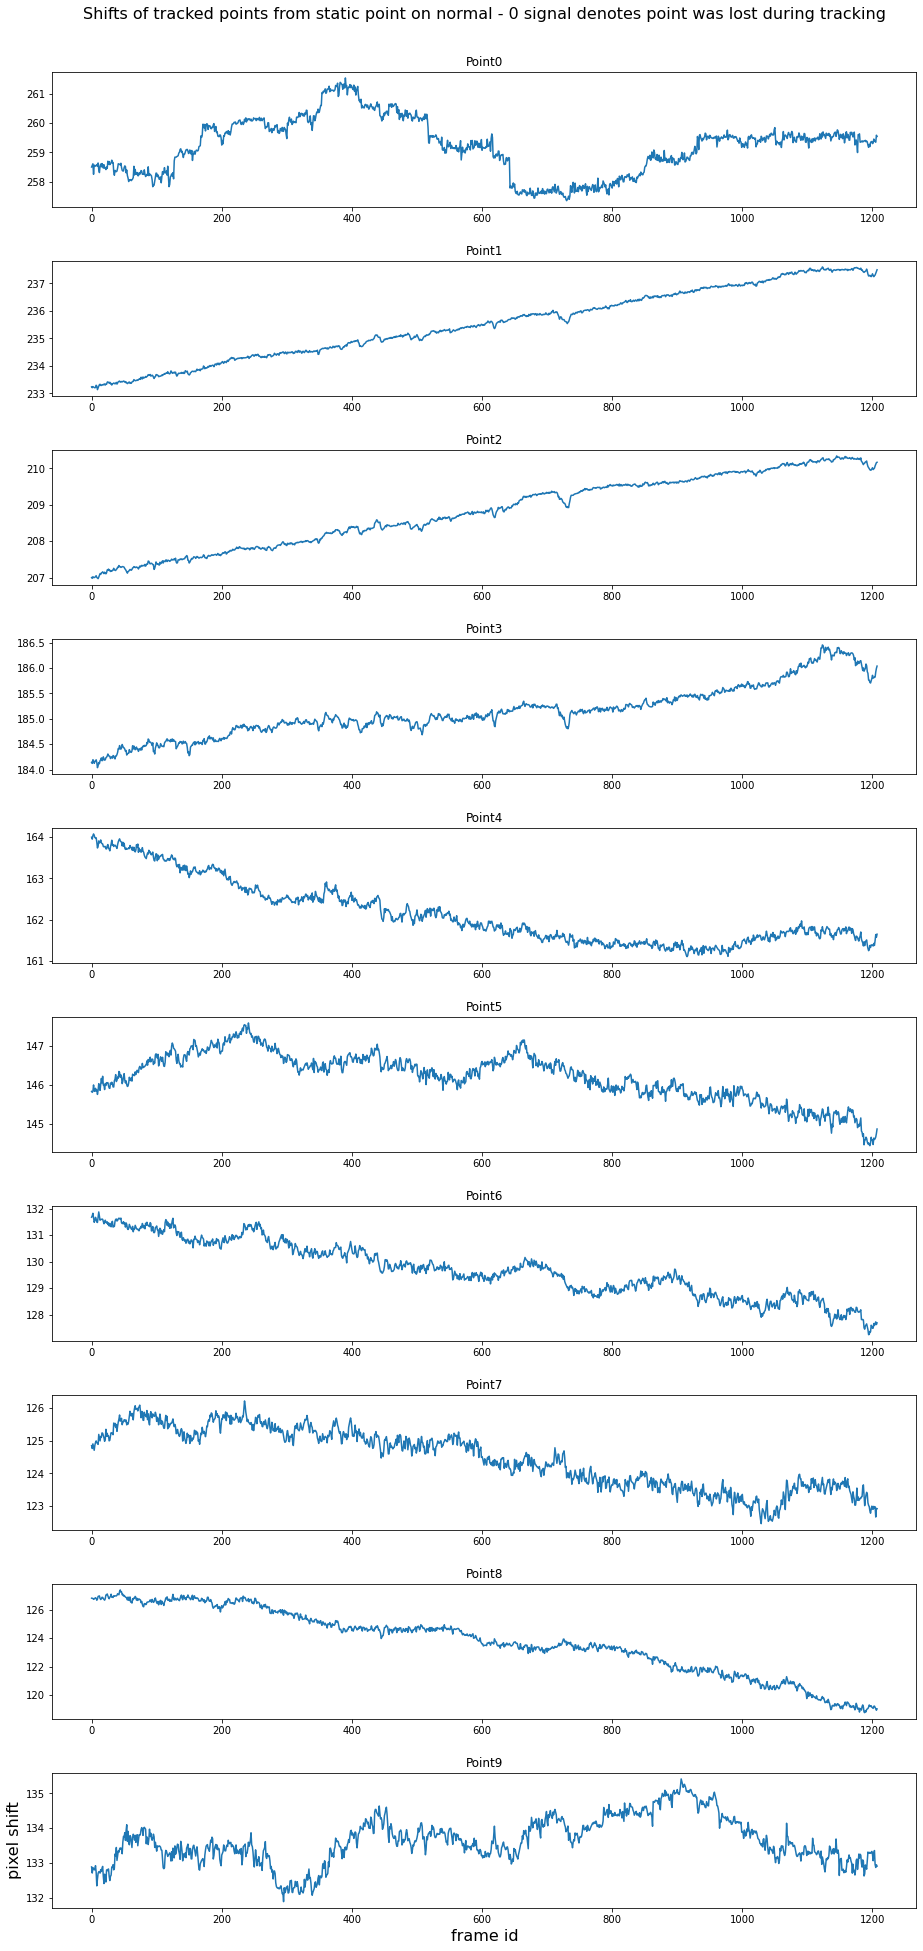

In [40]:
fig, ax = plt.subplots(10, figsize=(15,30))
fig.suptitle('Shifts of tracked points from static point on normal - 0 signal denotes point was lost during tracking', fontsize=16)
for i in range(10):
    ax[i].plot(np.arange(distances.shape[1]), distances[i,:])
    ax[i].set_title('Point'+str(i))
plt.xlabel('frame id', fontsize=16)
plt.ylabel('pixel shift', fontsize=16)
plt.subplots_adjust(left=0.1,
                    bottom=0.1, 
                    right=0.9, 
                    top=0.95, 
                    wspace=0.4, 
                    hspace=0.4)

### Save distance plots as numpy arrays

In [67]:
new_file = example_file.split('.')[0]+'.npy'
print('Shape of extracted signal: ', distances.shape)
np.save(new_file, distances)

## Extract signals for all videos

In [ ]:
for file in files:
    print('Opening file:' , example_file)
    vid = tifffile.imread(os.path.join(filepath, file))
    border_points, track_points, static_points = get_tracking_points(vid[0])
    distances, points_lost = track_points_in_vid(vid, track_points, static_points, view=True, wait=20) # view video and set frame rate
    new_file = file.split('.')[0]+'.npy'
    np.save(new_file, distances)

# Main process

## Work on new signal extraction from border extraction at every frame

For this approach we are assuming there is no drift of the organoids, or else, that the border area remains the same throughout the video. After examining the videos we see that this is not the case for:

 - 220516_No contraction videos.lif - O1450_2 curare II.tif -> **strong drift**

 - Strong contraction.lif - O1319_1a.tif -> **slight drift**
 
 - Strong contraction.lif - O1468_1b.tif -> **strong drift or strong contraction??**

In [19]:
filepath = dst_filepath

subsample = 10
wait = 1
view = True
save_np = False
subsample_regions = 10
    
for vid_id in range(len(files)):
    
    example_file = files[vid_id]
    print('Working on file: ', example_file)
    vid = tifffile.imread(os.path.join(filepath, example_file))
    
    distances = np.zeros((subsample_regions, vid.shape[0]//subsample))
    border_size = []
    rotated_masks = []
    
    # go once over entire video to get min length of border
    for frame_id in range(vid.shape[0]//subsample): 
        
        # extract border and sort pixels
        (x,y), _ = extract_border(vid[frame_id], sigma_smooth=2, sigma_edge=3)
        x, y = sort_border(x, y)
        
        # Rotate border so that is always parallel to x-axis
        theta = get_border_angle(x , y)
        mask = np.zeros(vid[frame_id].shape, dtype=bool)
        mask[(x,y)] = True #size 256, 256
        mask_r = rotate(mask, theta, resize=True) # shape usually 305,305 but changes
        
        # store rotated image and length of border
        y = np.sort(np.where(mask_r)[1])
        dist_y = y[-1] - y[0]
        border_size.append(dist_y)
        rotated_masks.append(mask_r)
        
    # get minimum border length
    border_size = np.array(border_size)
    #print('Mean:', np.mean(border_size), 'std:', np.std(border_size), 'min: ', np.min(border_size))
    bbox_size = np.min(border_size)
    if bbox_size%2==1: bbox_size-=1
    print('Border rectangle size: ', bbox_size)

    if view: cv2.destroyAllWindows()

    # and go a second time over to extract signals 
    for frame_id in range(vid.shape[0]//subsample):

        mask_r = rotated_masks[frame_id]

        # Pad so we always have a fixed size image
        resize_size = (512 - mask_r.shape[0], 512 - mask_r.shape[1])
        mask_r = np.pad(mask_r, ((resize_size[0]//2+mask_r.shape[0]%2, resize_size[0]//2), (resize_size[1]//2+mask_r.shape[1]%2, resize_size[1]//2)))

        # Translate always relative to middle of image and around median of columns
        if frame_id==0: 
            where_border = np.where(mask_r)
            mean_x = round(np.mean(where_border[0]))
            median_y = round(np.median(where_border[1]))
        # crop edges of border so hopefully we are always including the same border points
        mask_r = mask_r[mean_x-100:mean_x+100, median_y-bbox_size//2:median_y+bbox_size//2]
        
        # get new img size and size of subsampled regions
        new_height, new_width = mask_r.shape
        subsample_area = new_width//subsample_regions
        
        # get the average of coordinates in sub-region along the x-axis and subtract from average if frame0
        for i in range(subsample_regions):
            sub_area = mask_r[:,i*subsample_area:(i+1)*subsample_area]
            x_sub, _ = np.where(sub_area)
            if len(x_sub)==0: distances[i, frame_id] = 0
            else: distances[i, frame_id] = np.mean(x_sub)
        
        # Display
        if view:
            frame = cv2.cvtColor((mask_r*255).astype(np.uint8),cv2.COLOR_GRAY2RGB)
            #out.write(frame) # uncomment for video saving
            cv2.namedWindow(example_file) 
            cv2.moveWindow(example_file, 150,150) 
            for i in range(subsample_regions):
                frame = cv2.line(frame, (i*subsample_area, 0), (i*subsample_area, new_height-1), (0, 0, 255), thickness=1) 
                frame = cv2.circle(frame, (round(i*subsample_area+subsample_area//2), round(distances[i, frame_id])), radius=2, color=(0, 255, 0), thickness=-1)

            cv2.imshow(example_file, frame)
            k = cv2.waitKey(wait)
            if k == 27: break
    
    if save_np:
        for i in range(10):
            distances[i, :] -= distances[i,0]
        new_file = example_file+'.npy'
        np.save(new_file, distances)

Working on file:  O2573_1b_curare.tif
Border rectangle size:  270
Working on file:  O2652_1b_curare.tif
Border rectangle size:  248
Working on file:  O2542_2b_curare.tif
Border rectangle size:  254
Working on file:  O2652_1a_curare.tif
Border rectangle size:  252
Working on file:  O1498_1a_curare.tif
Border rectangle size:  250
Working on file:  O1450_1b_curare.tif
Border rectangle size:  246
Working on file:  O3199_1_curare.tif
Border rectangle size:  252
Working on file:  P766_1b.tif
Border rectangle size:  292
Working on file:  P918_1b_recovery_curare.tif
Border rectangle size:  248


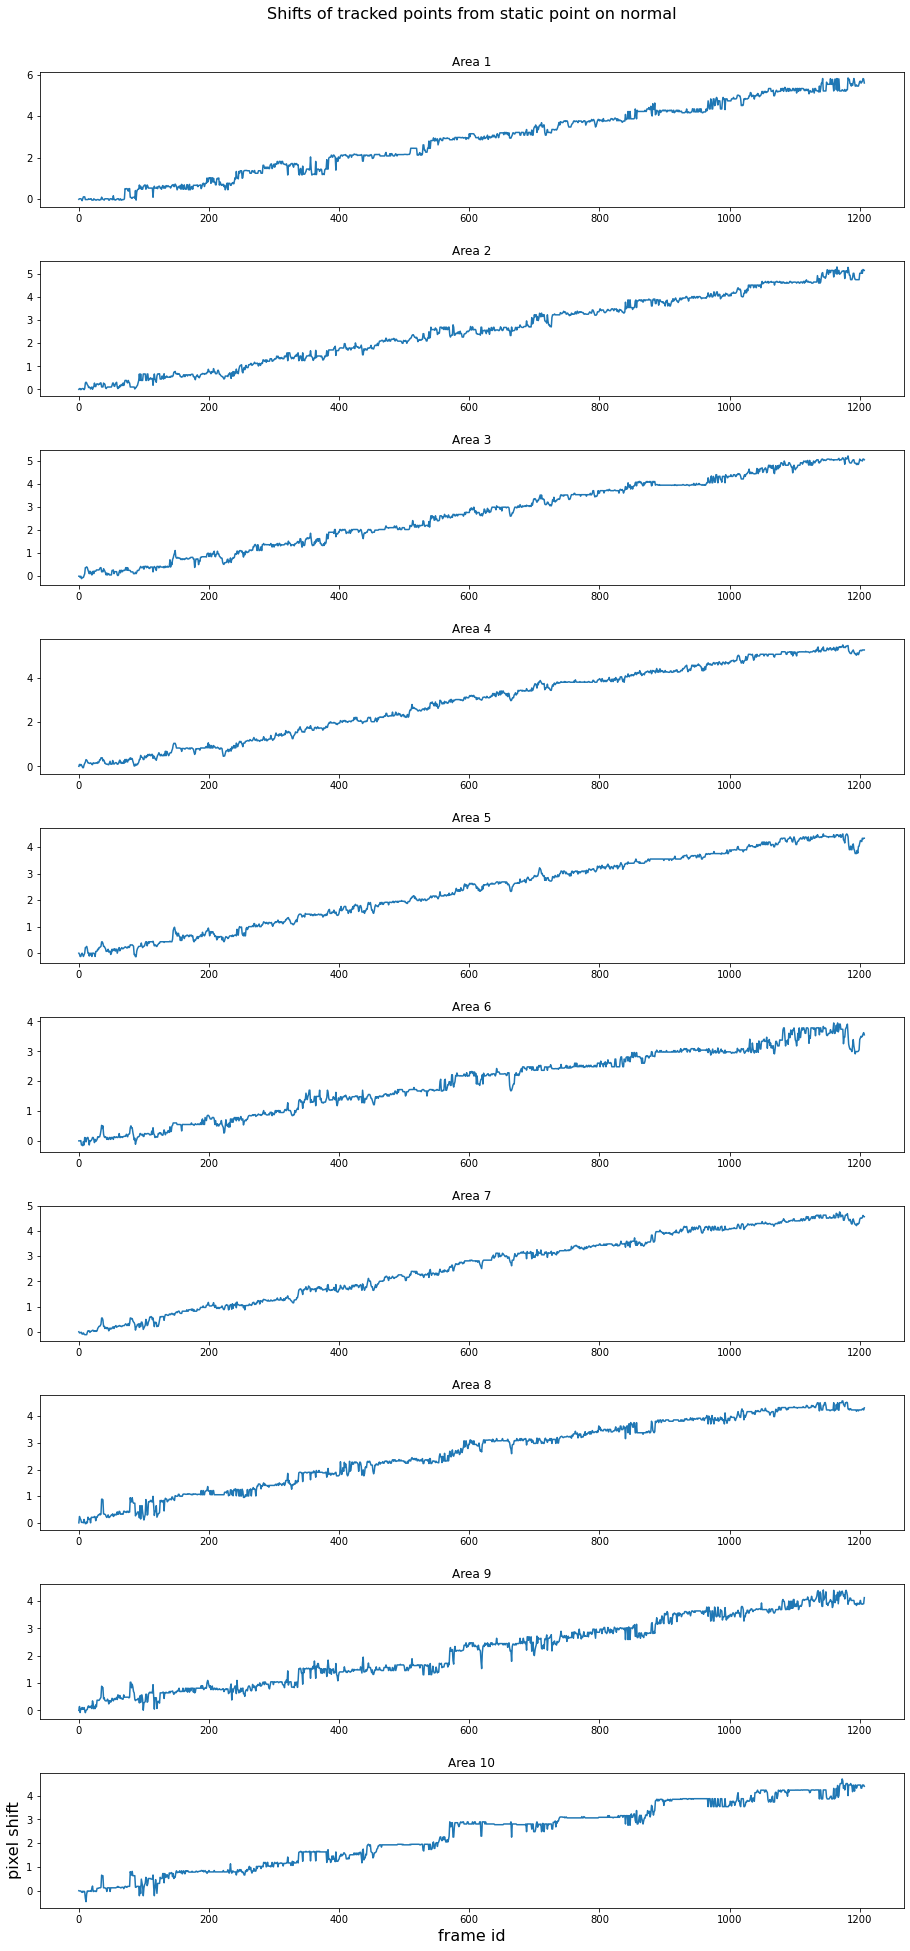

In [134]:
fig, ax = plt.subplots(10, figsize=(15,30))
fig.suptitle('Shifts of tracked points from static point on normal', fontsize=16)
for i in range(10):
    ax[i].plot(np.arange(distances.shape[1]), distances[i,:])
    ax[i].set_title('Area '+str(i+1))
plt.xlabel('frame id', fontsize=16)
plt.ylabel('pixel shift', fontsize=16)
plt.subplots_adjust(left=0.1,
                    bottom=0.1, 
                    right=0.9, 
                    top=0.95, 
                    wspace=0.4, 
                    hspace=0.4)

## Checking that signals were extarcted and stored correclty

File:  O3199_1_curare.tif.npy  with shape:  (10, 3015)
File:  P918_1b_recovery_curare.tif.npy  with shape:  (10, 3114)
File:  O2652_1b_curare.tif.npy  with shape:  (10, 3147)
File:  O2542_2b_curare.tif.npy  with shape:  (10, 3147)
File:  O2652_1a_curare.tif.npy  with shape:  (10, 3147)
File:  O1450_1b_curare.tif.npy  with shape:  (10, 1208)
File:  O1409_1b.tif.npy  with shape:  (10, 1813)
File:  O2652_2b_curare.tif.npy  with shape:  (10, 3147)
File:  P766_1b.tif.npy  with shape:  (10, 3147)
File:  O2573_1b_curare.tif.npy  with shape:  (10, 3147)
File:  O1498_1a_curare.tif.npy  with shape:  (10, 1208)
File:  O2542_1c_curare.tif.npy  with shape:  (10, 3147)


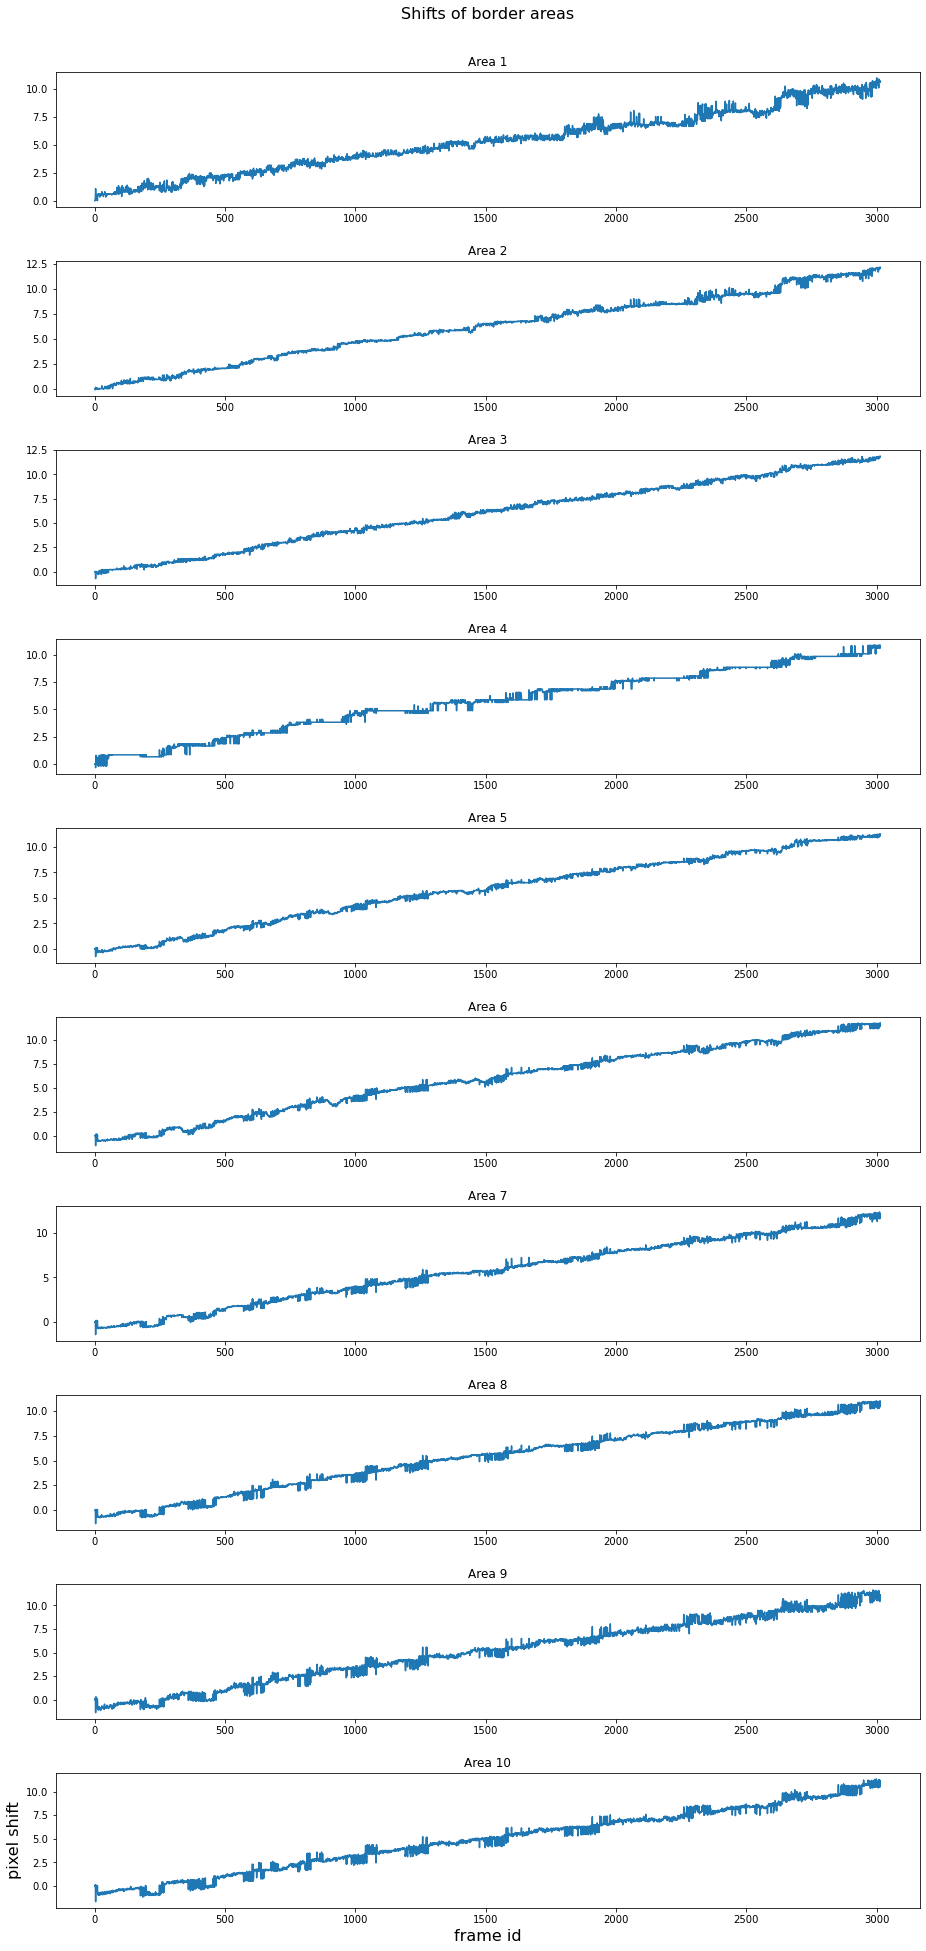

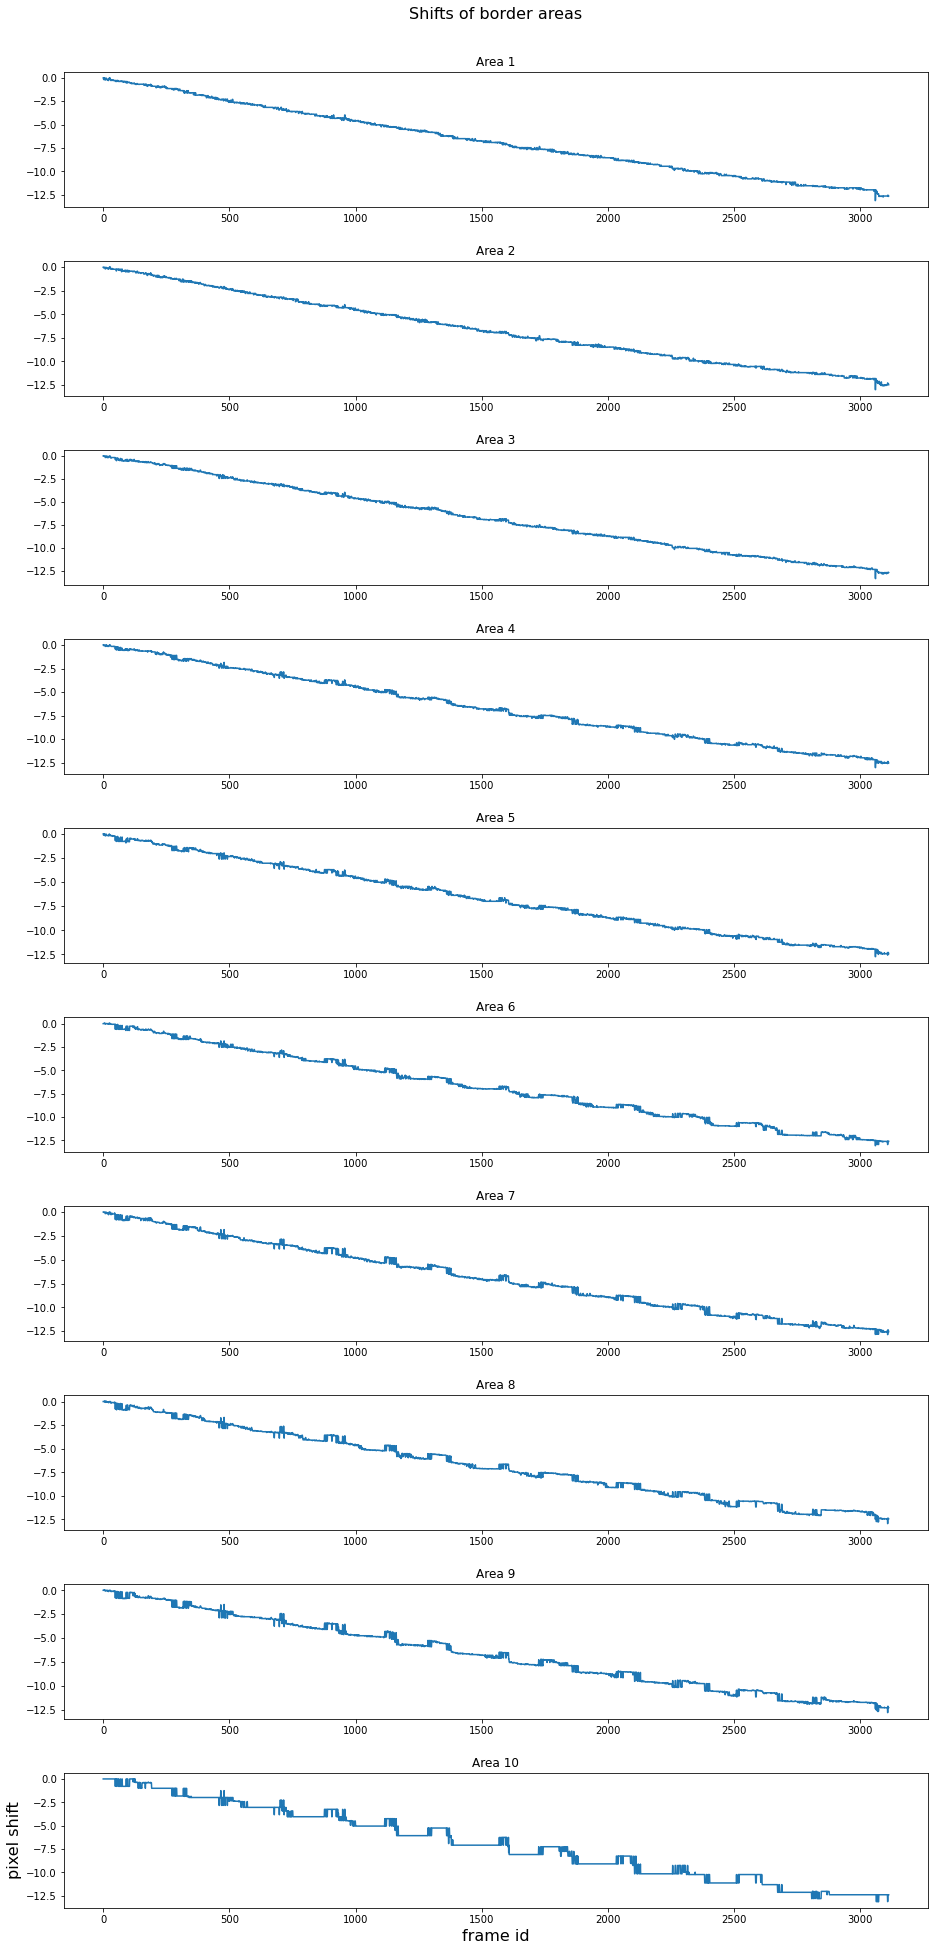

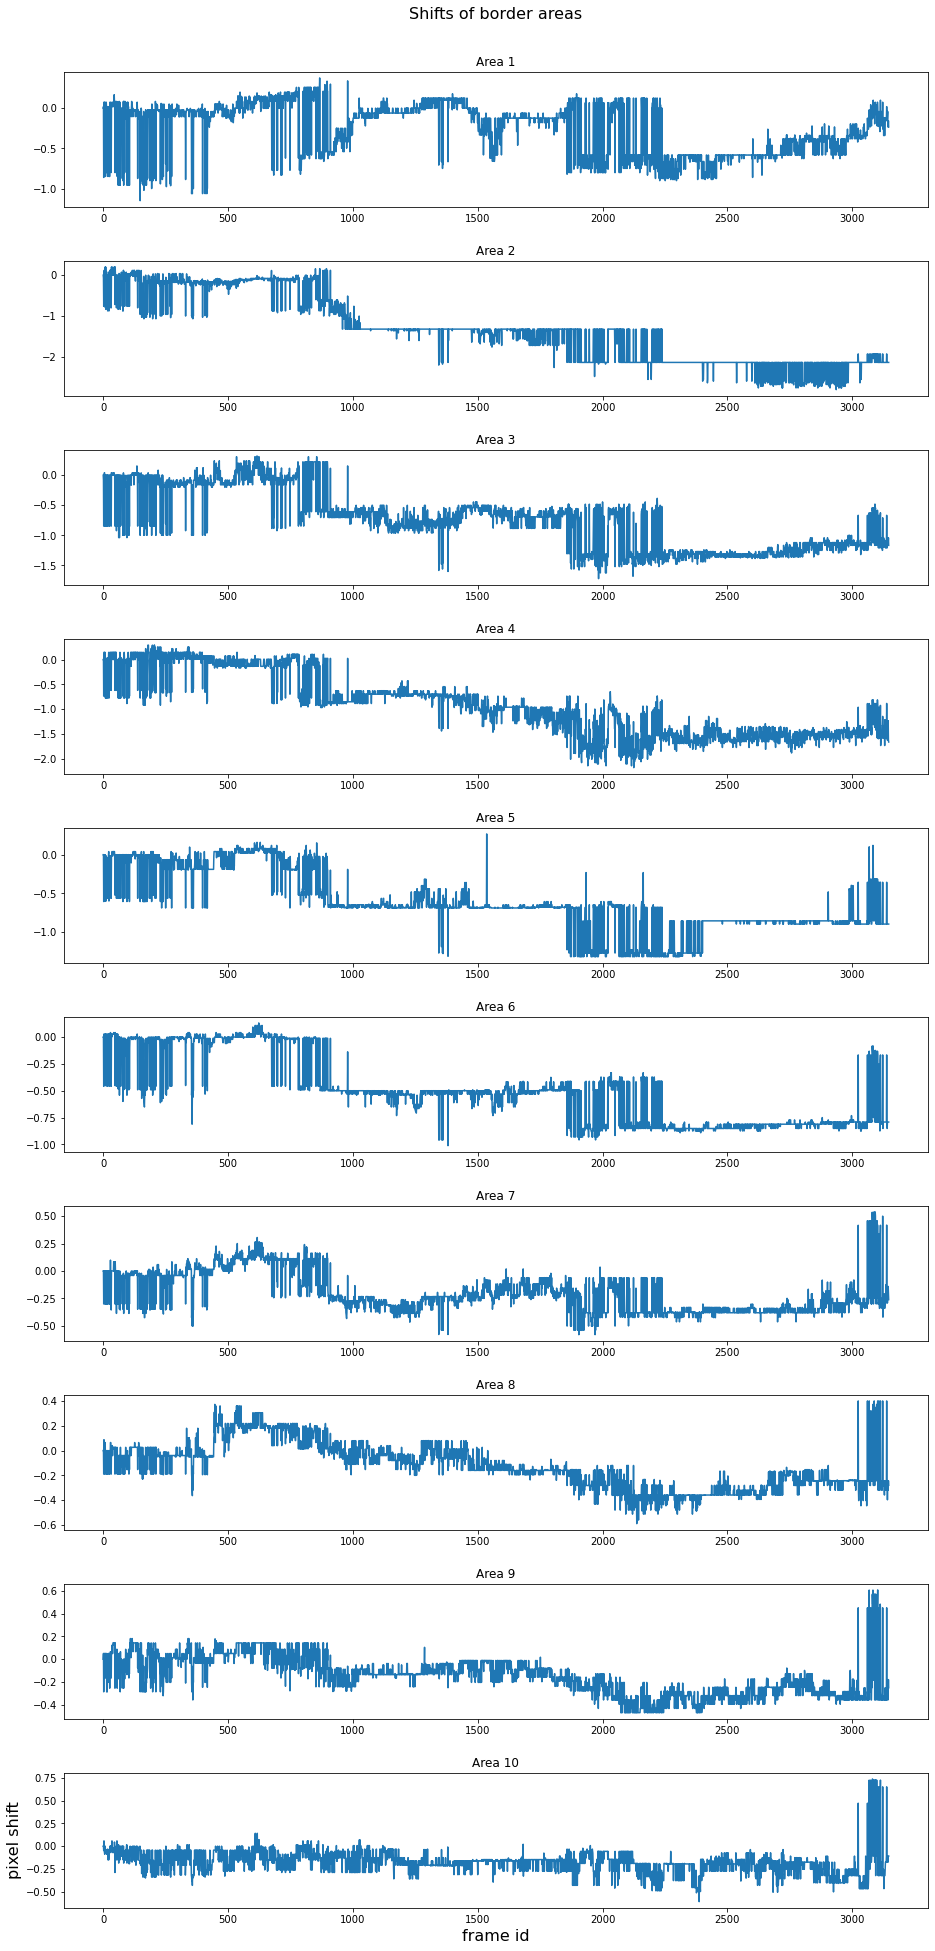

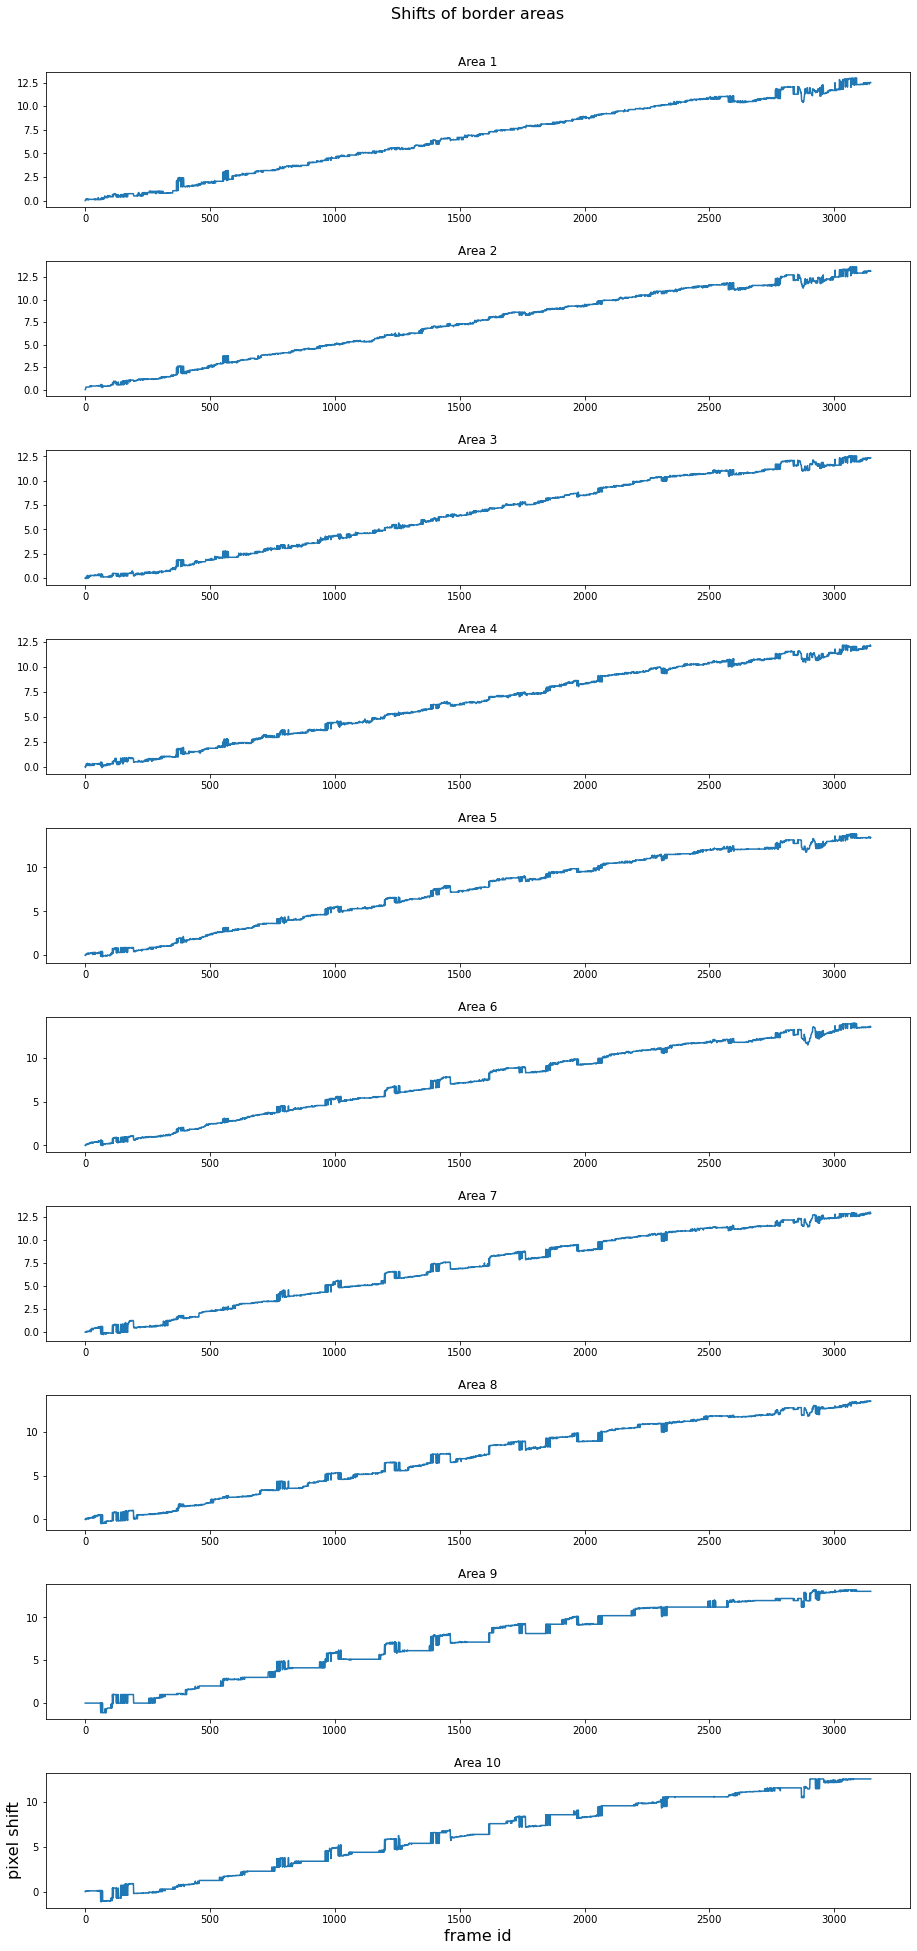

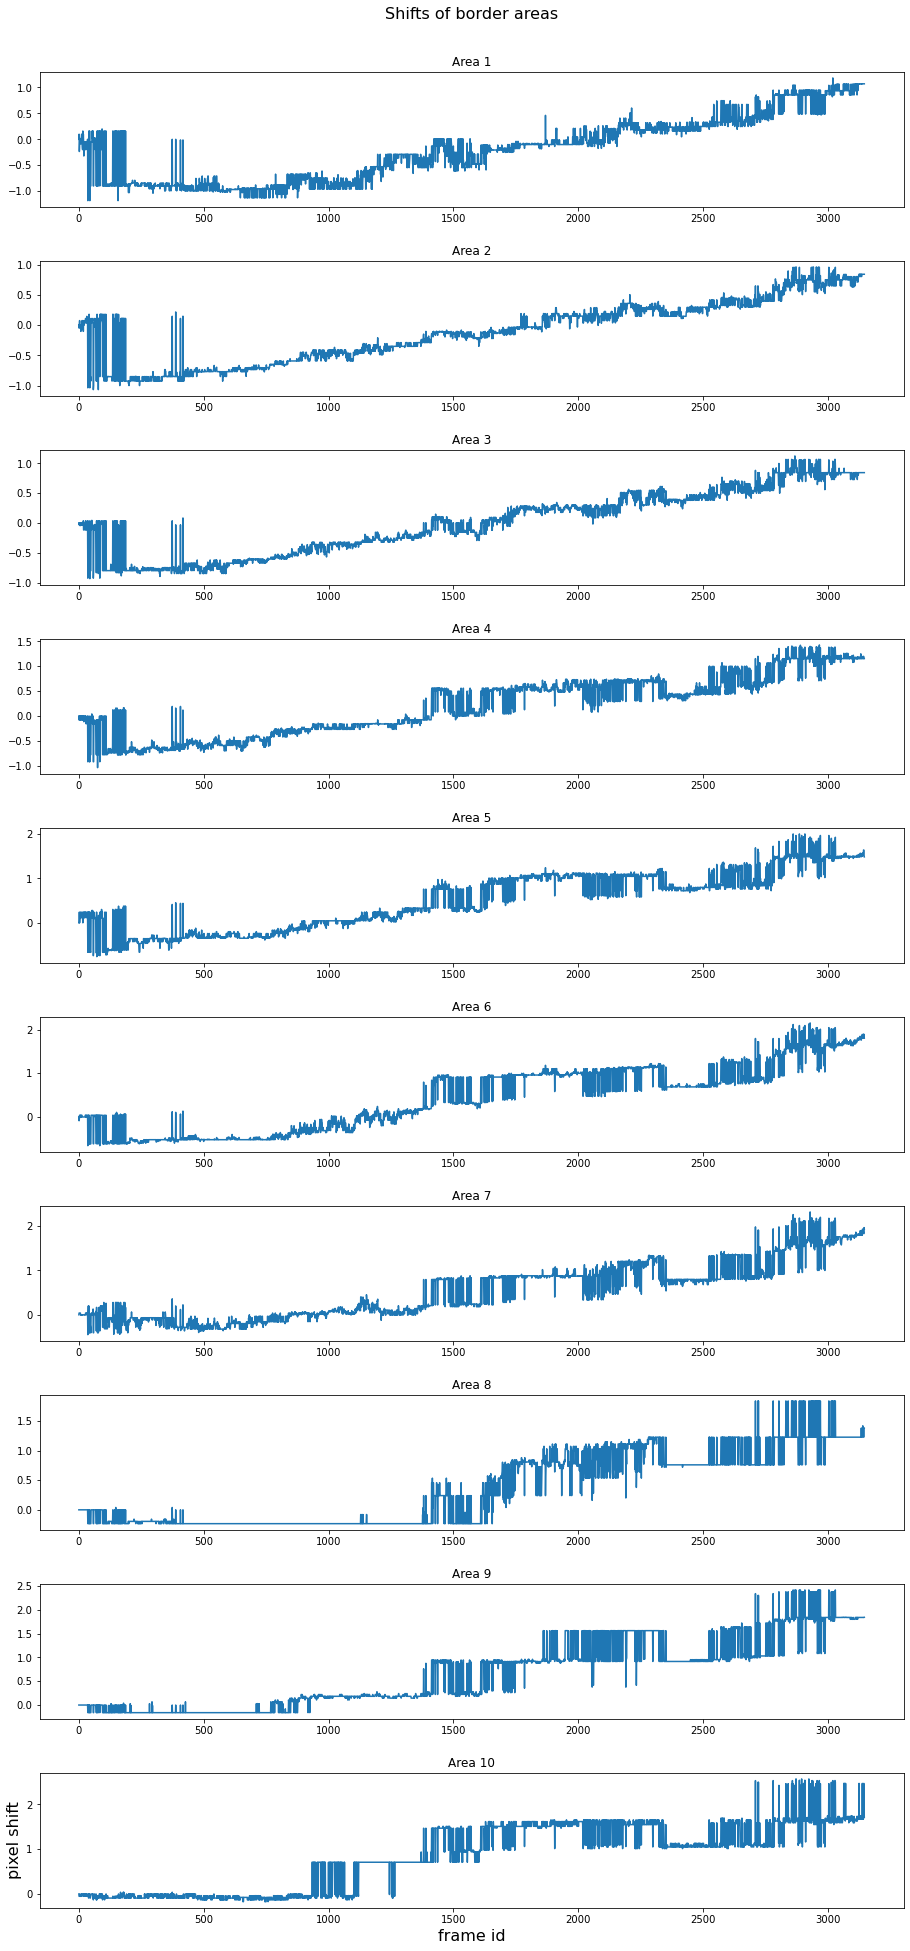

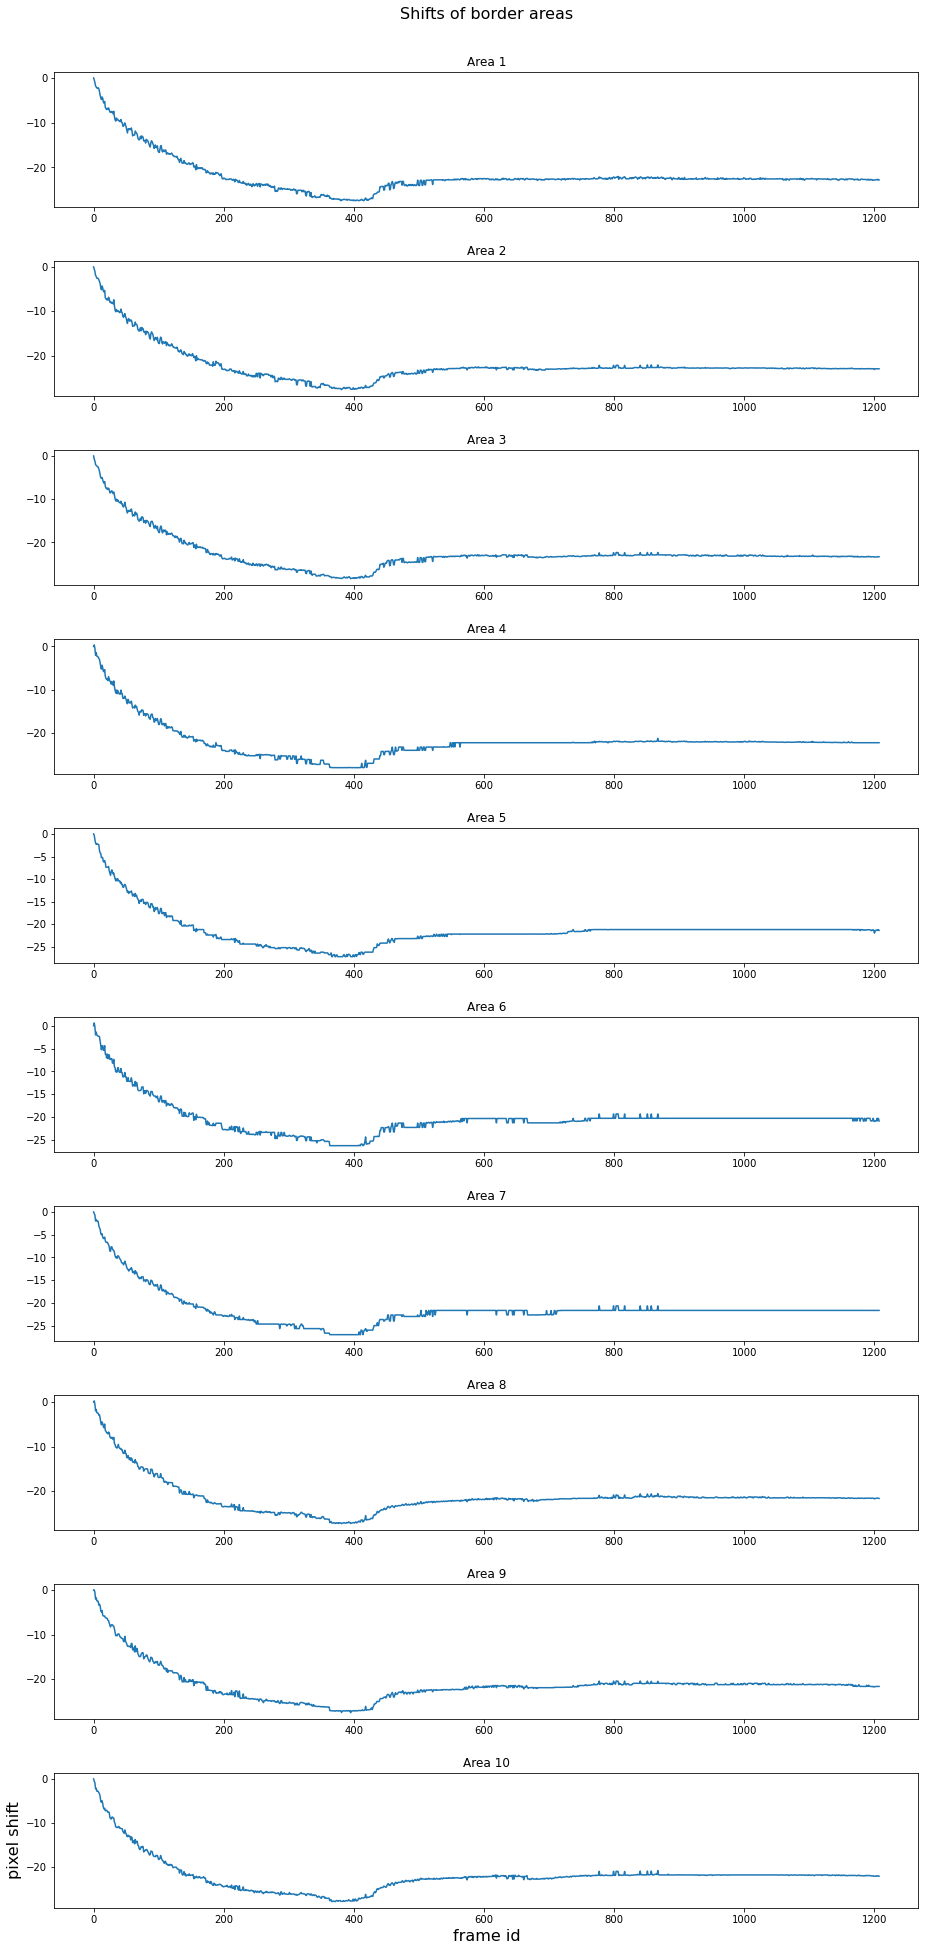

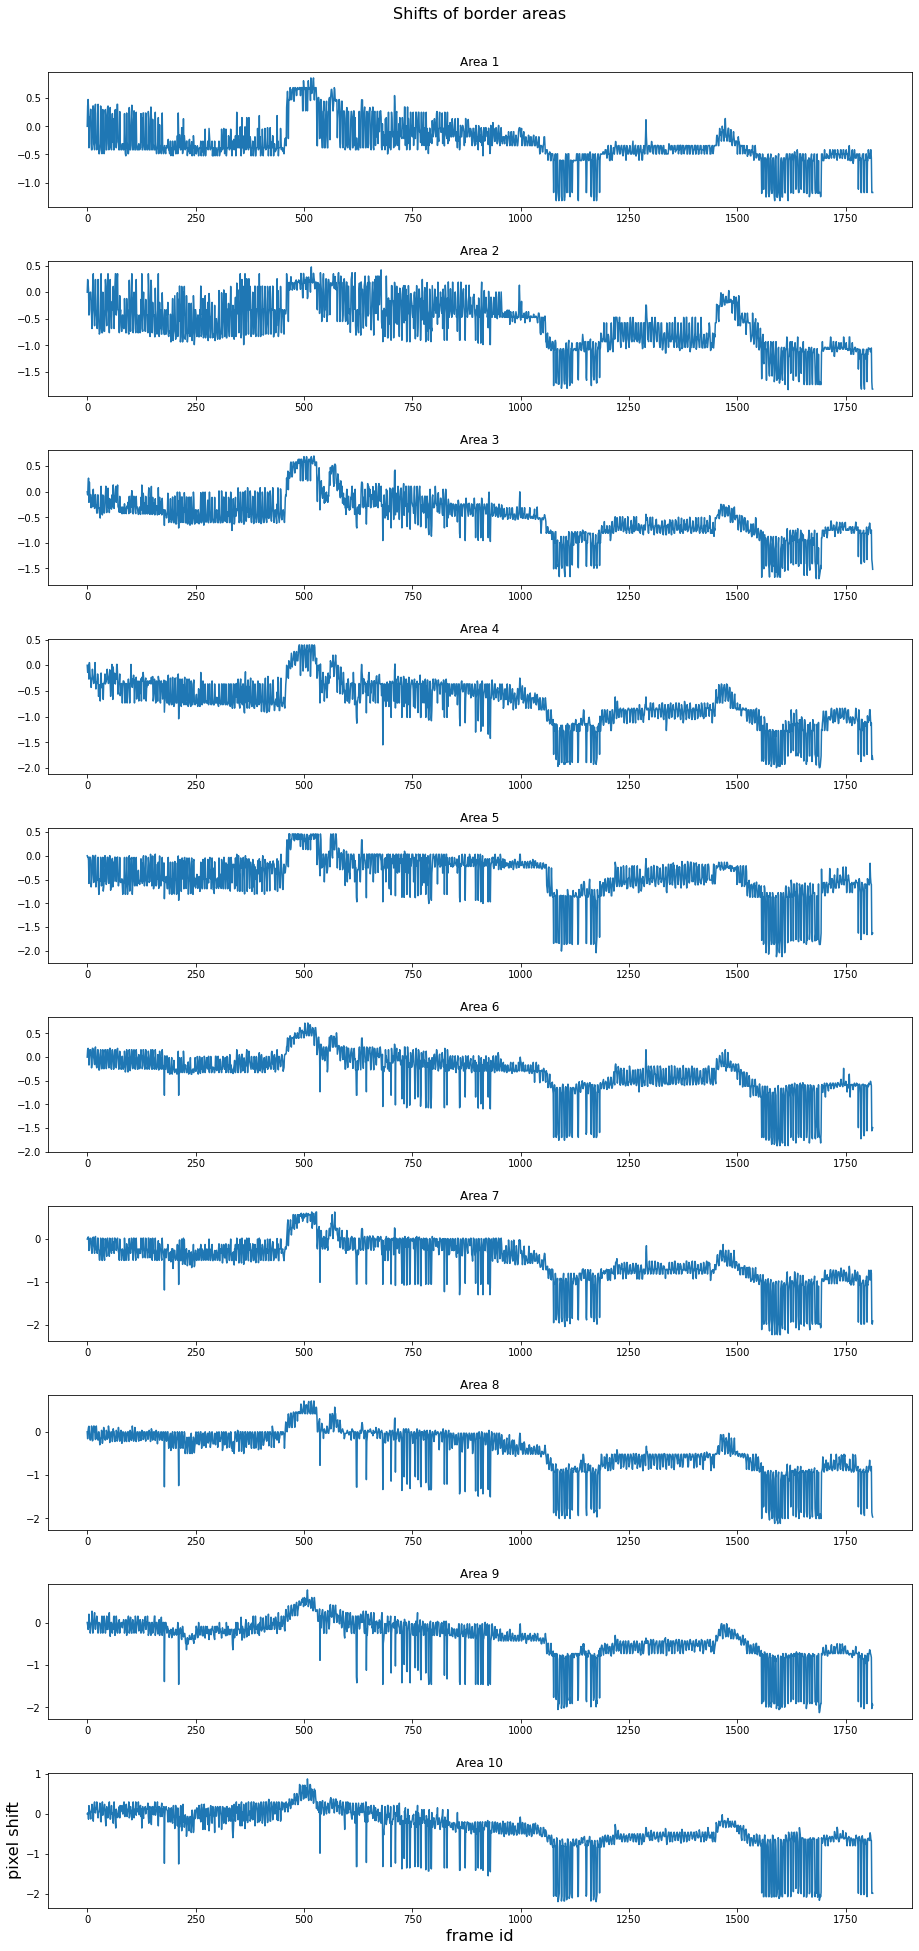

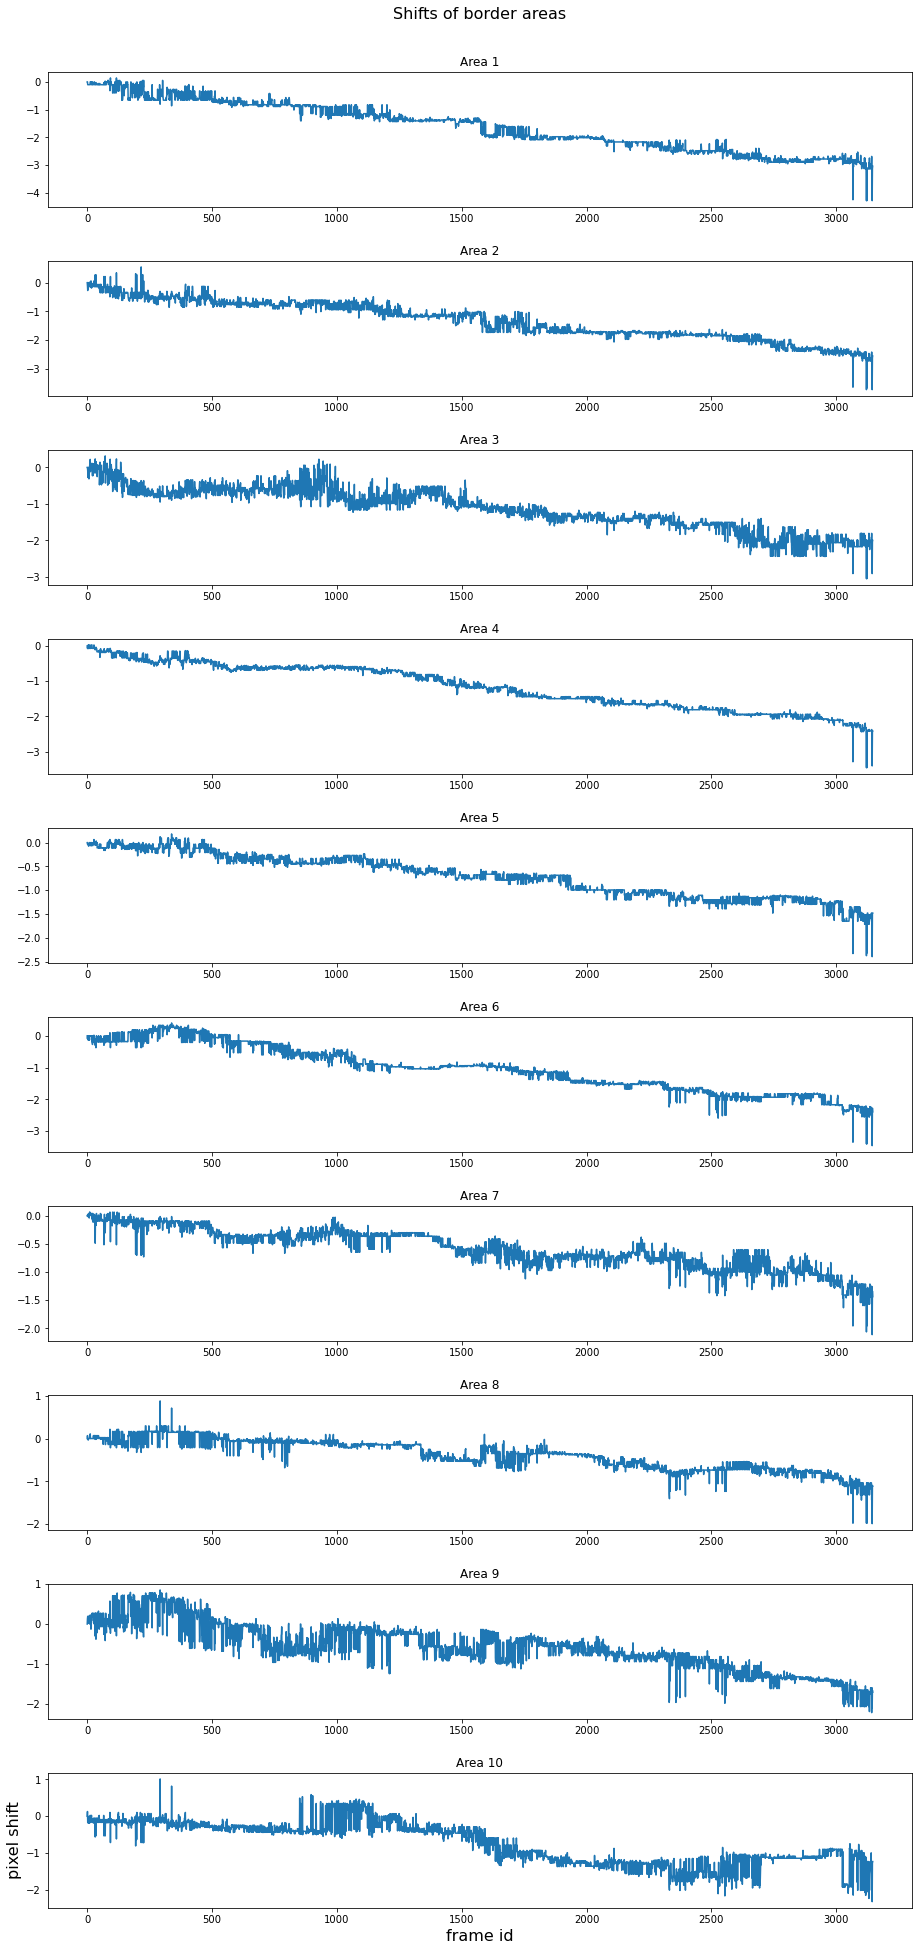

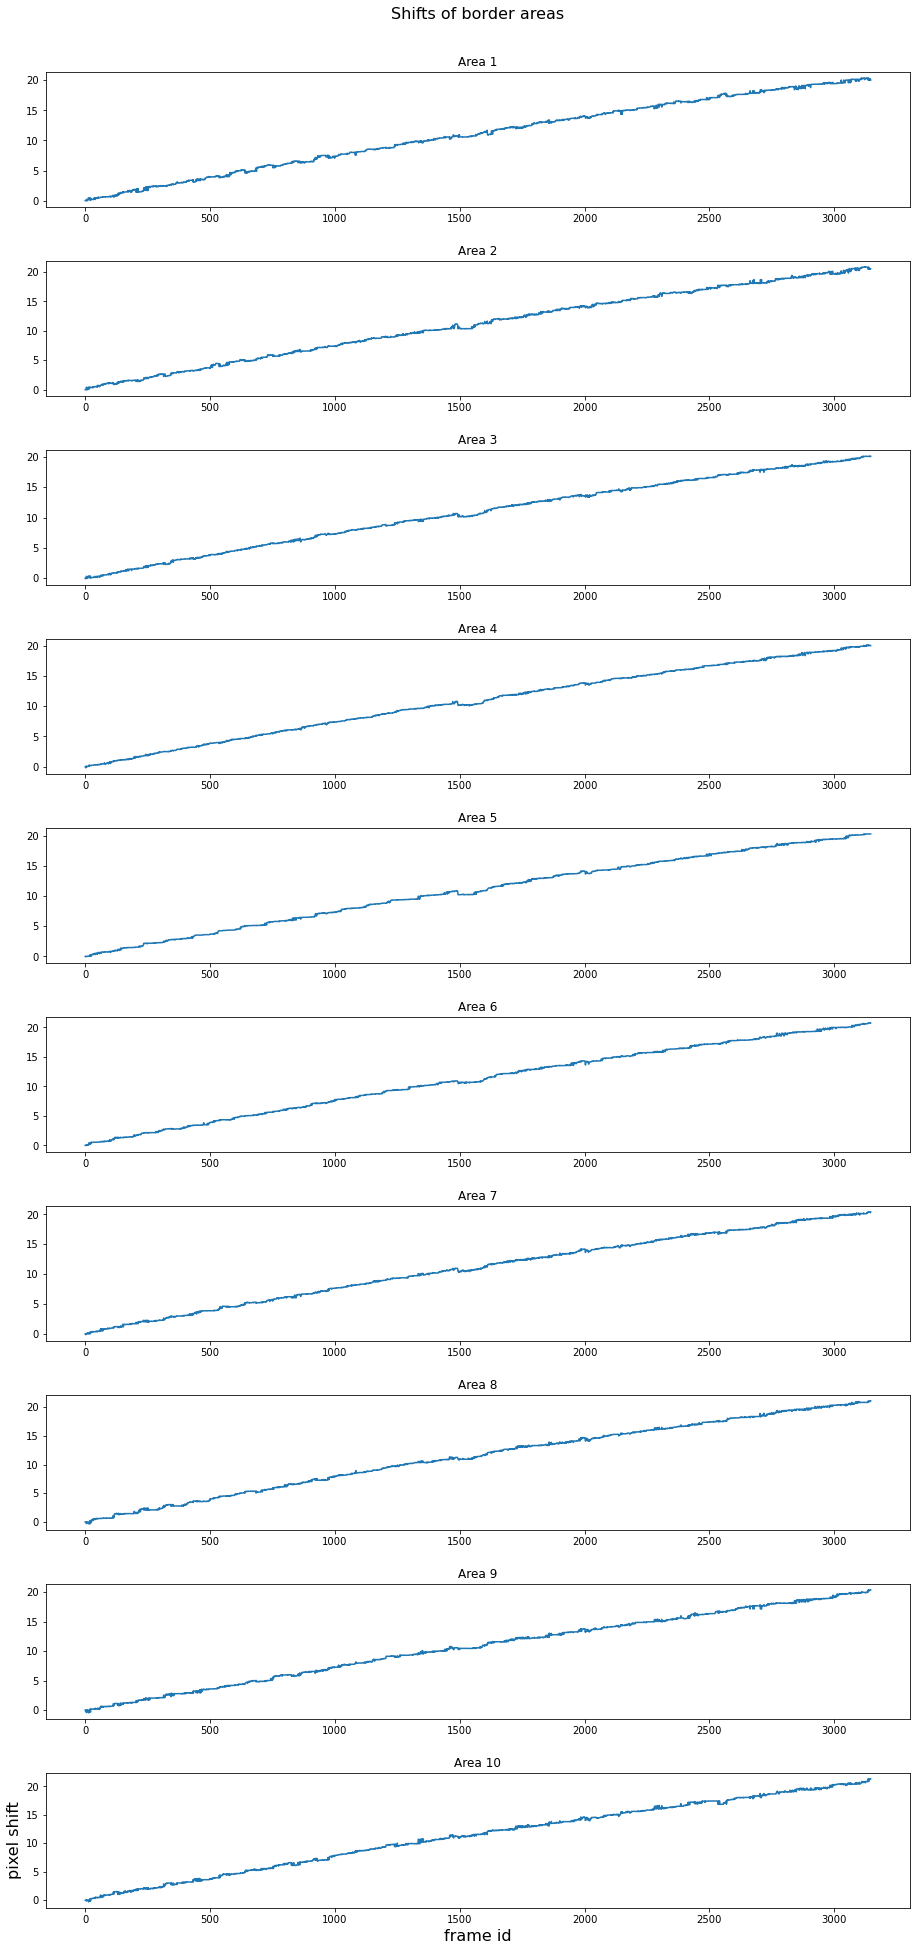

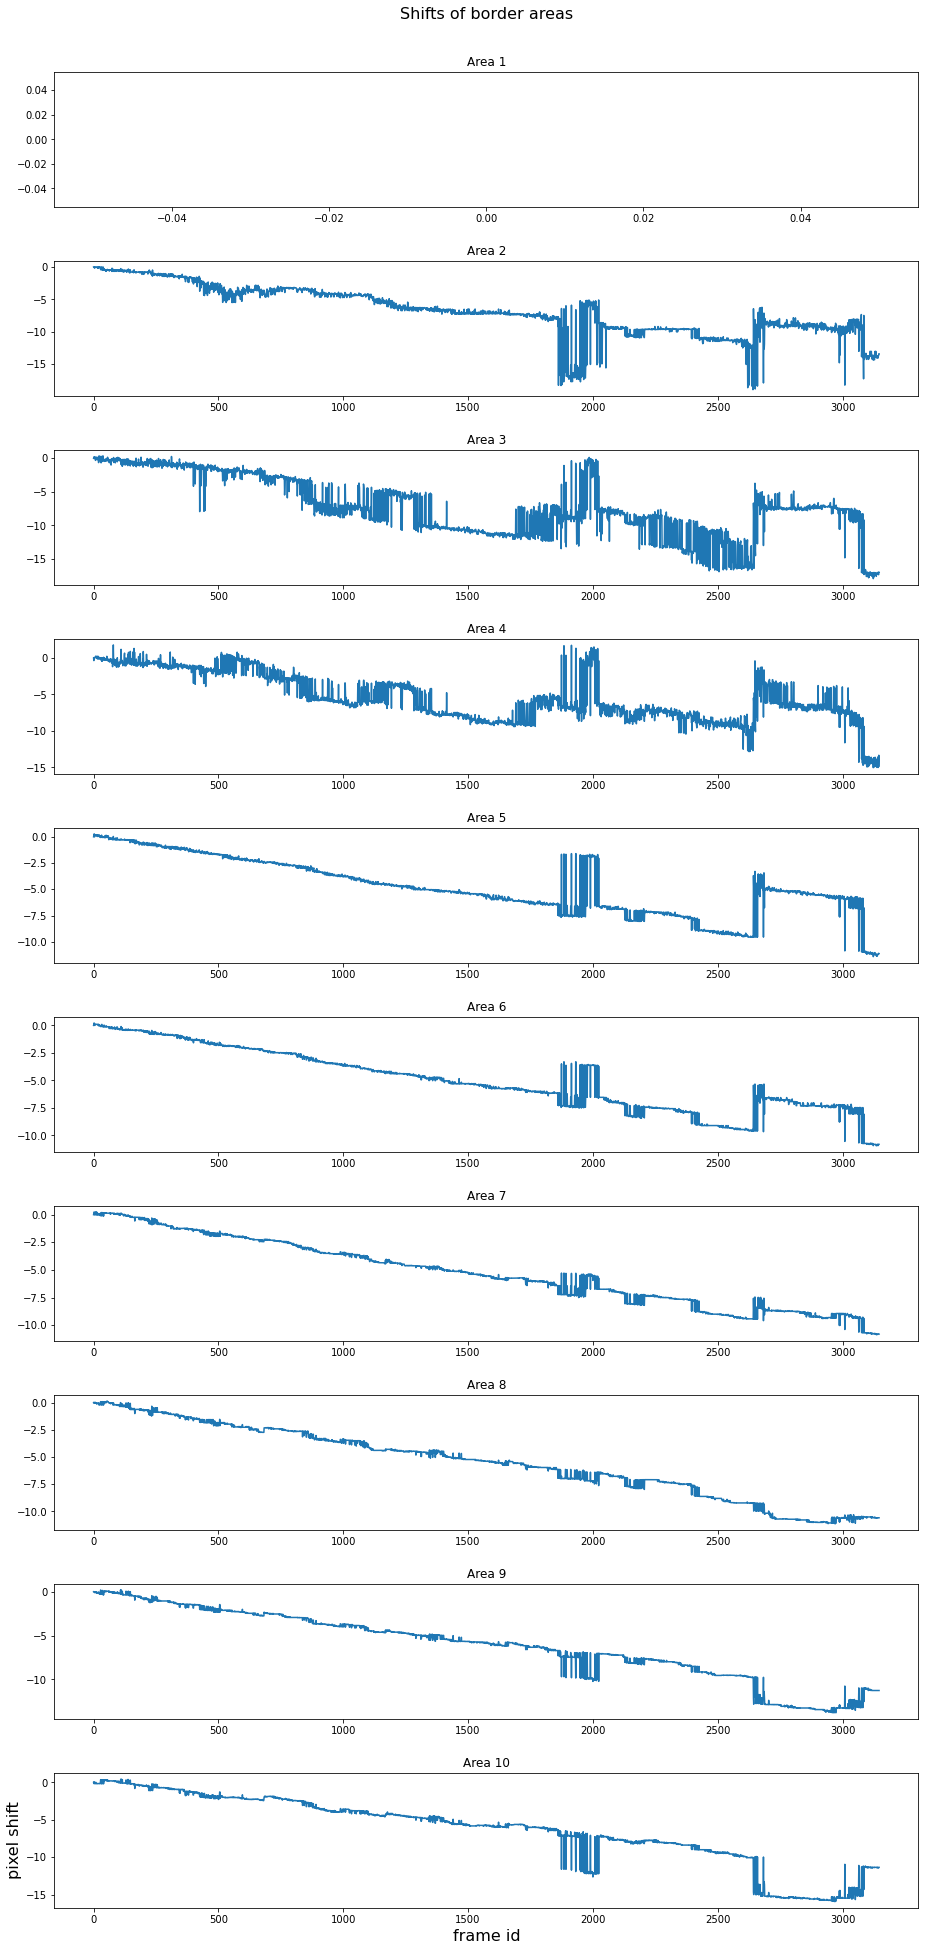

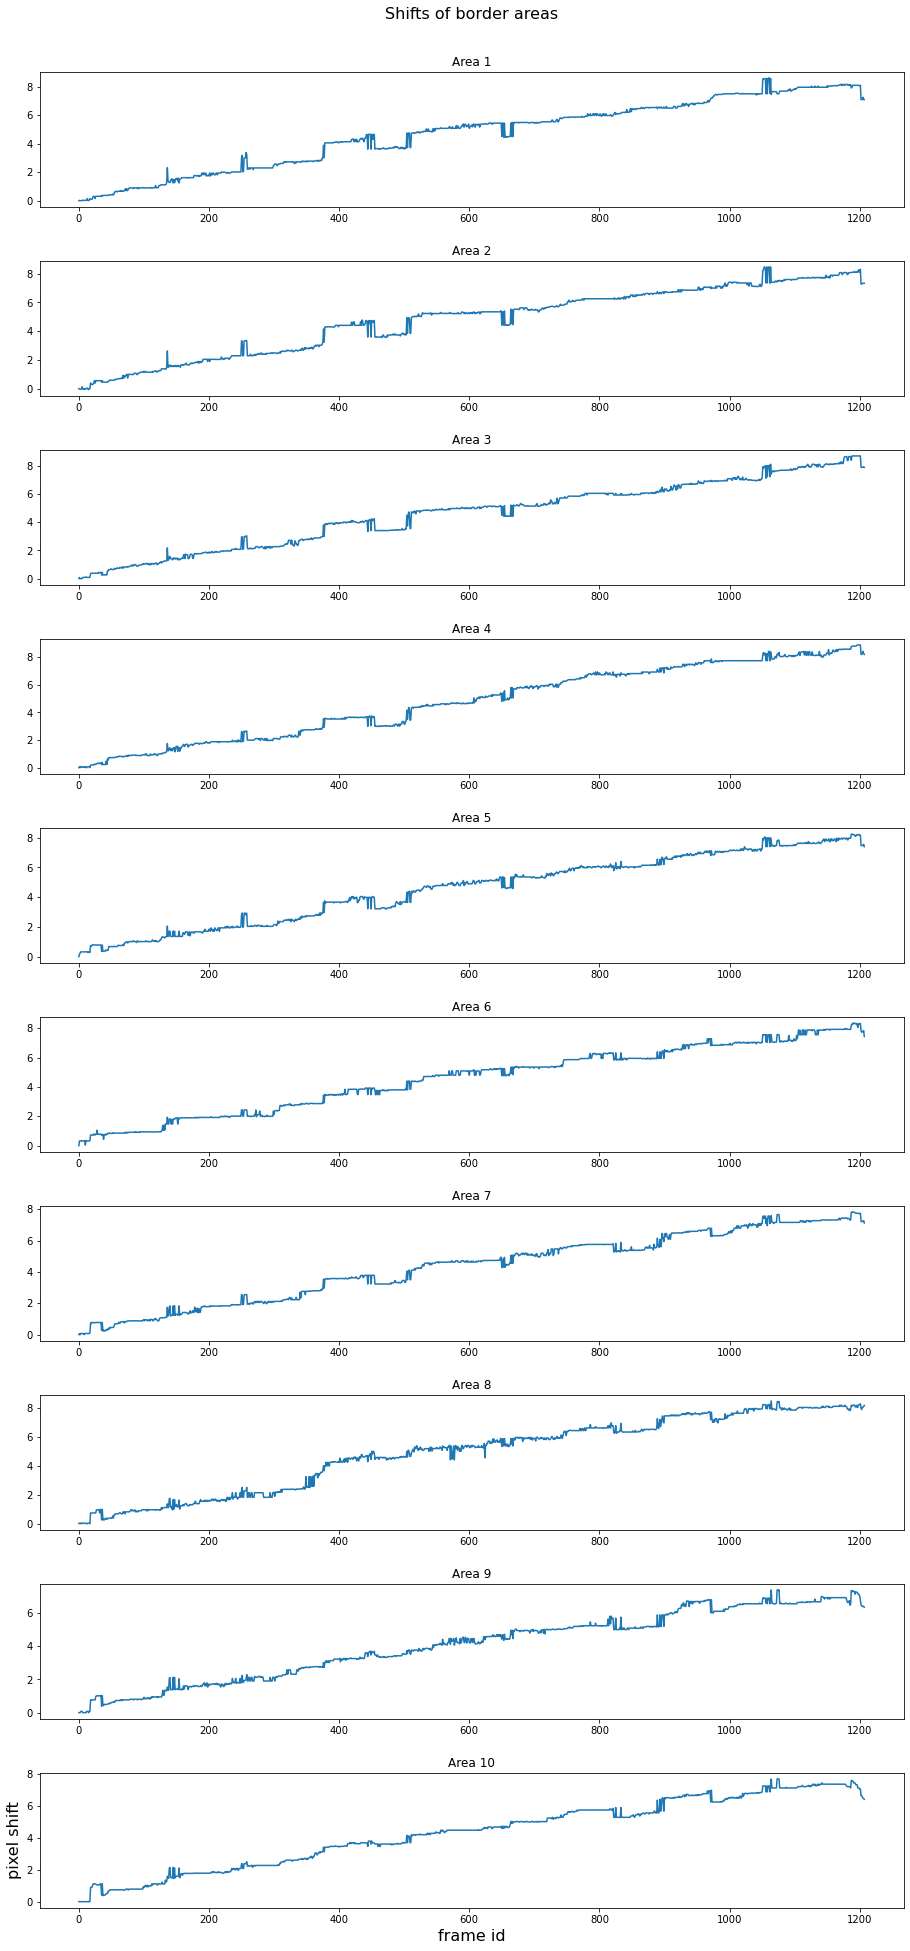

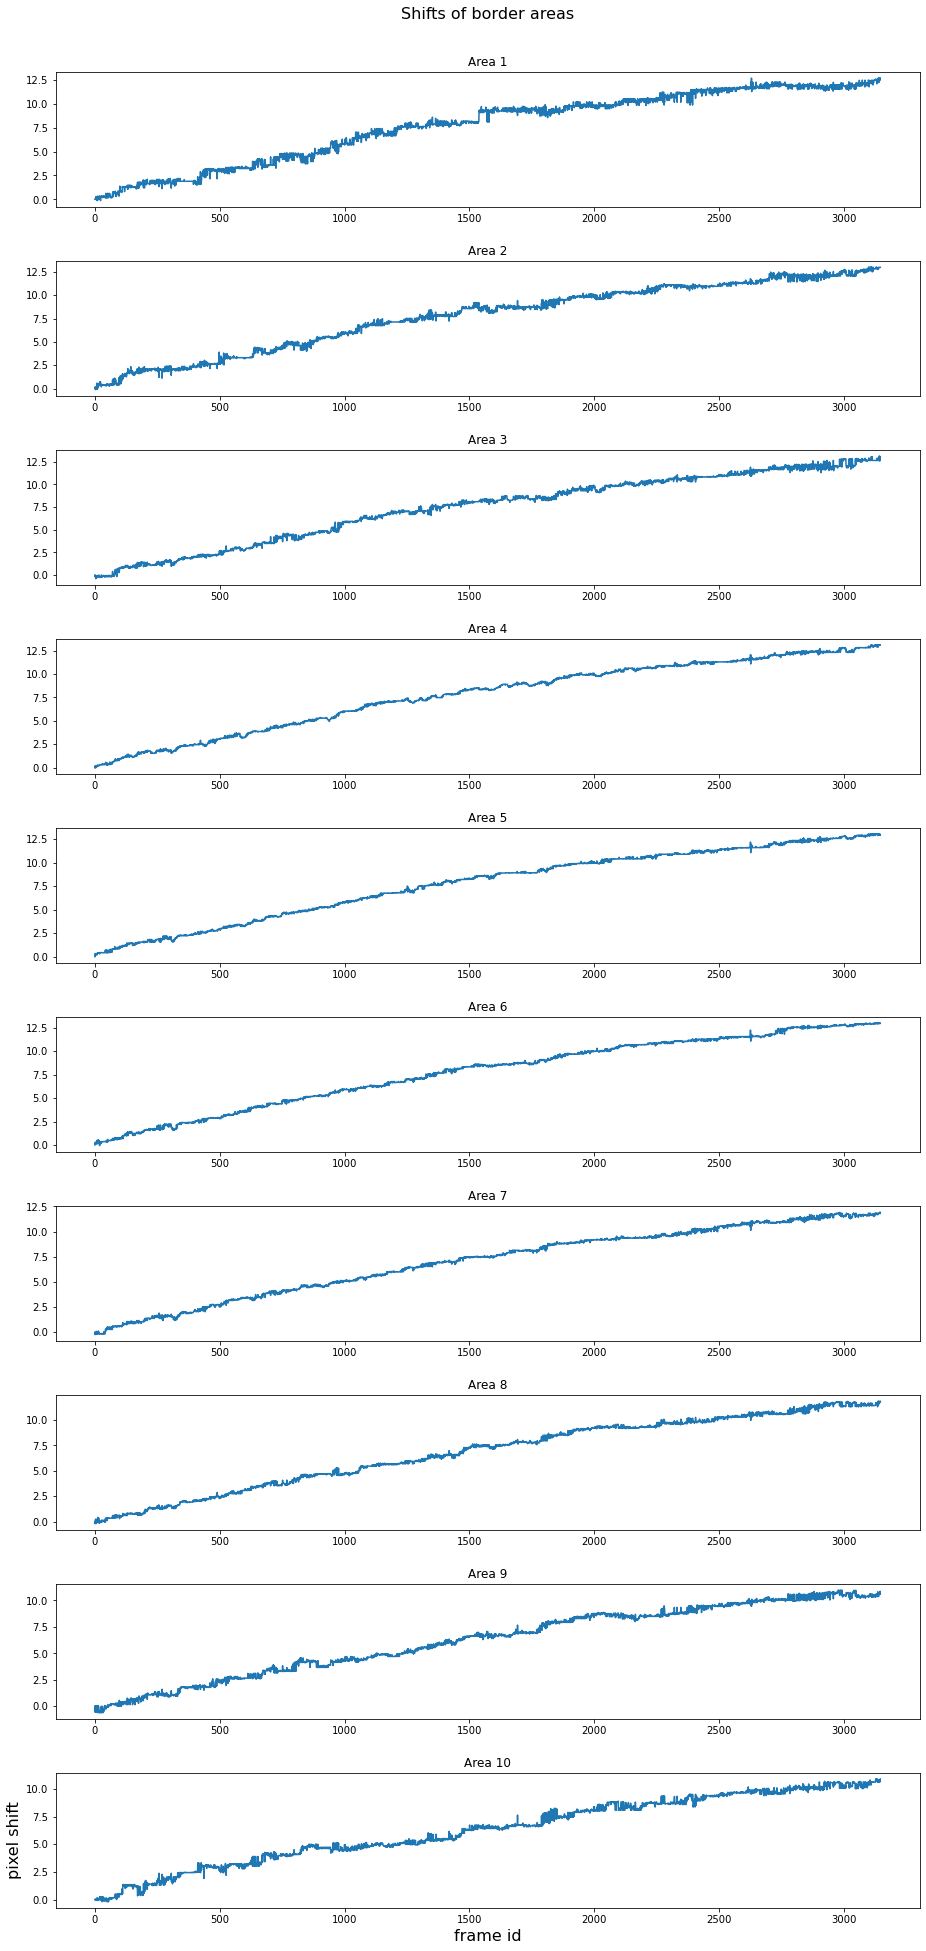

In [20]:
root_dir = 'extracted_signals_curare'
np_files=[file for file in os.listdir(root_dir) if file.endswith('.npy')]

#fig, ax = plt.subplots(15, figsize=(15,30))
#fig.suptitle('Shifts of border areas', fontsize=16)
    
for idx, file in enumerate(np_files):
    
    distances = np.load(os.path.join(root_dir, file))
    print('File: ', file, ' with shape: ', distances.shape)
    
    fig, ax = plt.subplots(10, figsize=(15,30))
    fig.suptitle('Shifts of border areas', fontsize=16)
    for i in range(10):
        ax[i].plot(np.arange(distances.shape[1]), distances[i,:])
        ax[i].set_title('Area '+str(i+1))
    '''
    # or plot for signal for each video
    ax[idx].plot(np.arange(distances.shape[1]), distances[0,:])
    ax[idx].set_title(file)
    '''  
    plt.xlabel('frame id', fontsize=16)
    plt.ylabel('pixel shift', fontsize=16)
    plt.subplots_adjust(left=0.1,
                        bottom=0.1, 
                        right=0.9, 
                        top=0.95, 
                        wspace=0.4, 
                        hspace=0.4)
    

## Generate comparable videos for one example and three methods

In [19]:
eg_file = '/Users/christina.bukas/Documents/Strong contraction.lif - O1468_1b.tif'
vid = tifffile.imread(eg_file)
vid.shape

(1208, 256, 256)

In [11]:
out = cv2.VideoWriter('orig.mp4',cv2.VideoWriter_fourcc('m', 'p', '4', 'v'), 25, (256,256))
vid_list = []
for i in range(vid.shape[0]):
    f = cv2.cvtColor(vid[i],cv2.COLOR_GRAY2RGB)
    vid_list.append(f)
for i in range(len(vid_list)):
    out.write(vid_list[i])
out.release()

In [ ]:
out = cv2.VideoWriter('wo_lose_points.mp4',cv2.VideoWriter_fourcc('m', 'p', '4', 'v'), 25, (256,256))
_, track_points, static_points = get_tracking_points(vid[0])
# add out as parameter if you wish to save video
distances, points_lost, _, frames = track_points_in_vid(eg_file, vid, track_points, static_points, lose_points=False, view=True, wait=1, subsample=1) # view video and set frame rate
for i in range(len(frames)):
    out.write(frames[i])
out.release()

In [45]:
subsample = 1
wait = 1
view = True
subsample_regions = 10

distances = np.zeros((subsample_regions, vid.shape[0]//subsample))
border_size = []
rotated_masks = []
frames1 = []
frames2 = []

# go once over entire video to get min length of border
for frame_id in range(vid.shape[0]//subsample): 

    # extract border and sort pixels
    (x,y), _ = extract_border(vid[frame_id], sigma_smooth=2, sigma_edge=3)
    x, y = sort_border(x, y)

    # Rotate border so that is always parallel to x-axis
    theta = get_border_angle(x , y)
    mask = np.zeros(vid[frame_id].shape, dtype=bool)
    mask[(x,y)] = True #size 256, 256
    
    frames1.append(cv2.cvtColor((mask*255).astype(np.uint8),cv2.COLOR_GRAY2RGB))
    
    mask_r = rotate(mask, theta, resize=True) # shape usually 305,305 but changes

    # store rotated image and length of border
    y = np.sort(np.where(mask_r)[1])
    dist_y = y[-1] - y[0]
    border_size.append(dist_y)
    rotated_masks.append(mask_r)

# get minimum border length
border_size = np.array(border_size)
#print('Mean:', np.mean(border_size), 'std:', np.std(border_size), 'min: ', np.min(border_size))
bbox_size = np.min(border_size)
if bbox_size%2==1: bbox_size-=1
print('Border rectangle size: ', bbox_size)

if view: cv2.destroyAllWindows()

# and go a second time over to extract signals 
for frame_id in range(vid.shape[0]//subsample):

    mask_r = rotated_masks[frame_id]

    # Pad so we always have a fixed size image
    resize_size = (512 - mask_r.shape[0], 512 - mask_r.shape[1])
    mask_r = np.pad(mask_r, ((resize_size[0]//2+mask_r.shape[0]%2, resize_size[0]//2), (resize_size[1]//2+mask_r.shape[1]%2, resize_size[1]//2)))

    # Translate always relative to middle of image and around median of columns
    if frame_id==0: 
        where_border = np.where(mask_r)
        mean_x = round(np.mean(where_border[0]))
        median_y = round(np.median(where_border[1]))
    # crop edges of border so hopefully we are always including the same border points
    mask_r = mask_r[mean_x-100:mean_x+100, median_y-bbox_size//2:median_y+bbox_size//2]

    # get new img size and size of subsampled regions
    new_height, new_width = mask_r.shape
    subsample_area = new_width//subsample_regions

    # get the average of coordinates in sub-region along the x-axis and subtract from average if frame0
    for i in range(subsample_regions):
        sub_area = mask_r[:,i*subsample_area:(i+1)*subsample_area]
        x_sub, _ = np.where(sub_area)
        distances[i, frame_id] = np.mean(x_sub)

    # Display
    if view:
        frame = cv2.cvtColor((mask_r*255).astype(np.uint8),cv2.COLOR_GRAY2RGB)
        #out.write(frame) # uncomment for video saving
        cv2.namedWindow(eg_file) 
        cv2.moveWindow(eg_file, 150,150) 
        for i in range(subsample_regions):
            frame = cv2.line(frame, (i*subsample_area, 0), (i*subsample_area, new_height-1), (0, 0, 255), thickness=1) 
            frame = cv2.circle(frame, (round(i*subsample_area+subsample_area//2), round(distances[i, frame_id])), radius=5, color=(0, 255, 0), thickness=-1)

        cv2.imshow(eg_file, frame)
        k = cv2.waitKey(wait)
        if k == 27: break
            
    frames2.append(frame)

Border rectangle size:  246


In [46]:
out = cv2.VideoWriter('border.mp4',cv2.VideoWriter_fourcc('m', 'p', '4', 'v'), 25, (256,256))
for i in range(len(frames1)):
    out.write(frames1[i])
out.release()

In [47]:
w, h = frames2[0].shape[1], frames2[0].shape[0] # (200,246,3)
out = cv2.VideoWriter('signal-extraction.mp4',cv2.VideoWriter_fourcc('m', 'p', '4', 'v'), 25, (w,h))
for i in range(len(frames)):
    out.write(frames[i])
out.release()